# AusLAMP Victoria: Combined EDL and LEMI-424 Dataset Analysis

**Goal**: Exploratory analysis comparing EDL and LEMI-424 MT datasets from Victoria.

**Datasets**:
- **EDL**: ASCII daily files from `E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_2026\`
- **LEMI-424**: Text daily files from `E:\MT_Timeseries_DATA\MT_AusLAMP_GA\LEMI_raw\`

**Analysis**:
1. Site location maps (EDL vs LEMI-424 instruments)
2. Metadata comparison (instrument, site, duration)
3. Statistical analysis (mean values, standard deviations)
4. Data quality comparison

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import Markdown, display

# Pandas display options
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

def caption(text):
    """Display a figure caption as wrapped, italic markdown."""
    display(Markdown(f"*{text}*"))

## LEMI-424 Reader

In [2]:
class LEMI424Reader:
    """
    Reads and processes data from a LEMI-424 text file.
    
    LEMI-424 data format:
    - Space-delimited text files
    - One file per day
    - Columns: year month day hour minute second Bx By Bz TE TF E1 E2 E3 E4 UIN H lat lat_hem lon lon_hem n_sats gps_bind_time time_diff
    - Magnetic fields already calibrated (nT)
    - Electric fields in mV/km
    
    Usage:
        reader = LEMI424Reader("path/to/file.TXT", log_first_rows=True)
        df = reader.read()
    """

    def __init__(self, file_path, log_first_rows=False):
        self.file_path = file_path
        self.log_first_rows = log_first_rows
        self.data = None

    def read(self):
        """
        Reads the text file and returns a pandas DataFrame indexed by datetime.
        """
        try:
            # Define column names matching the file structure
            cols = [
                "year", "month", "day", "hour", "minute", "second",
                "Bx", "By", "Bz", "TE", "TF",
                "E1", "E2", "E3", "E4", "UIN", "H",
                "lat", "lat_hem", "lon", "lon_hem",
                "n_sats", "gps_bind_time", "time_diff"
            ]
            # Use sep=r'\s+' instead of deprecated delim_whitespace
            df = pd.read_csv(self.file_path, sep=r'\s+', names=cols, engine='python')

            if self.log_first_rows:
                print(f"First 3 rows of {Path(self.file_path).name}:")
                print(df.head(3))
                print()

            # Combine to datetime
            df['datetime'] = pd.to_datetime(df[['year','month','day','hour','minute','second']])

            # Coordinate conversion helper
            def conv_coord(val, hemi):
                deg = int(val // 100)
                minutes = val - deg*100
                decimal = deg + minutes/60
                if hemi in ['S','W']:
                    decimal = -decimal
                return decimal

            df['latitude'] = df.apply(lambda r: conv_coord(r['lat'], r['lat_hem']), axis=1)
            df['longitude'] = df.apply(lambda r: conv_coord(r['lon'], r['lon_hem']), axis=1)

            # Set index
            df.set_index('datetime', inplace=True)
            df.drop(columns=["year","month","day","hour","minute","second",
                             "lat","lat_hem","lon","lon_hem"], inplace=True)

            # Rename electric channels for consistency (E1, E2 -> Ex, Ey)
            df = df.rename(columns={'E1': 'Ex', 'E2': 'Ey'})

            self.data = df
            return df

        except Exception as e:
            print(f"Error reading {self.file_path}: {e}")
            return None

## Load EDL Site Metadata

In [3]:
# EDL exported data directory
edl_dir = Path(r'E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_2026')

# Get all EDL site directories
edl_sites = sorted([d for d in edl_dir.glob('VIC*') if d.is_dir()])

print(f"Found {len(edl_sites)} EDL sites")
print(f"Sites: {[s.name for s in edl_sites[:10]]}...")

Found 81 EDL sites
Sites: ['VIC001', 'VIC002', 'VIC003', 'VIC005', 'VIC006', 'VIC007', 'VIC008', 'VIC010', 'VIC011', 'VIC013']...


In [4]:
# Extract metadata from EDL sites
edl_metadata = []

for site_dir in edl_sites:
    site_id = site_dir.name
    
    # Get all .dat files
    dat_files = sorted(list(site_dir.glob('*.dat')))
    
    if len(dat_files) == 0:
        continue
    
    # Read first file to get coordinates
    try:
        first_file = dat_files[0]
        df_sample = pd.read_csv(first_file, sep=' ', nrows=1)
        
        # Parse start time from first file
        start_time = pd.to_datetime(df_sample['DateTime'].iloc[0])
        
        # Parse end time from last file (read last row)
        last_file = dat_files[-1]
        df_last = pd.read_csv(last_file, sep=' ')
        end_time = pd.to_datetime(df_last['DateTime'].iloc[-1])
        
        # For EDL, we need to get coordinates from the original metadata
        # For now, we'll load from the QA/QC CSV if it exists
        
        edl_metadata.append({
            'site_id': site_id,
            'instrument': 'EDL',
            'start_time': start_time,
            'end_time': end_time,
            'duration_days': (end_time - start_time).total_seconds() / 86400,
            'n_files': len(dat_files)
        })
        
    except Exception as e:
        print(f"Error reading {site_id}: {e}")
        continue

edl_metadata_df = pd.DataFrame(edl_metadata)
print(f"\nExtracted metadata for {len(edl_metadata_df)} EDL sites")
edl_metadata_df.head()


Extracted metadata for 81 EDL sites


,site_id,instrument,start_time,end_time,duration_days,n_files
0,VIC001,EDL,2014-04-11 06:00:00,2014-05-08 00:59:59.900,26.79,28
1,VIC002,EDL,2014-05-13 00:00:00,2014-06-06 03:59:59.900,24.17,25
2,VIC003,EDL,2014-05-12 03:00:00,2014-06-06 22:59:59.900,25.83,26
3,VIC005,EDL,2014-05-11 00:00:00,2014-05-28 22:59:59.900,17.96,18
4,VIC006,EDL,2014-04-06 07:00:00,2014-05-08 21:59:59.900,32.62,33


In [5]:
# Load EDL coordinates and metadata from MTH5 files
# Note: MTH5 files contain station location and orientation info,
# but sensor/instrument details are not populated (set to "none").
# This is why we use the re-calibrated EDL_2026 data for analysis.

sys.path.insert(0, str(Path.cwd().parent / 'src'))
from mth5_metadata import extract_all_metadata

mth5_dir = Path(r'E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5')
mth5_metadata_df = extract_all_metadata(mth5_dir)

print(f"\nMTH5 metadata extracted for {len(mth5_metadata_df)} EDL sites")
print(f"Columns: {', '.join(mth5_metadata_df.columns.tolist())}")

# Merge MTH5 metadata into edl_metadata_df
edl_metadata_df = edl_metadata_df.merge(
    mth5_metadata_df[['station_id', 'latitude', 'longitude', 'elevation', 'declination',
                      'declination_model', 'acquired_by', 'data_type', 'orientation_method', 
                      'orientation_frame', 'comments', 'channels_recorded']], 
    left_on='site_id', 
    right_on='station_id', 
    how='left'
)
edl_metadata_df = edl_metadata_df.drop('station_id', axis=1)

print(f"\nMerged coordinates for {edl_metadata_df['latitude'].notna().sum()} EDL sites")
print(f"\nFirst 5 sites with metadata:")
display(edl_metadata_df[['site_id', 'latitude', 'longitude', 'elevation', 'declination', 
                         'orientation_method', 'channels_recorded']].head())

# Show any sites with important comments
sites_with_comments = edl_metadata_df[edl_metadata_df['comments'].notna() & 
                                       (edl_metadata_df['comments'] != 'nan')]
if len(sites_with_comments) > 0:
    print(f"\n\nSites with special comments ({len(sites_with_comments)}):")
    for idx, row in sites_with_comments.iterrows():
        print(f"  {row['site_id']}: {row['comments']}")

Found 81 MTH5 files in E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5
Successfully extracted metadata from 81 files

MTH5 metadata extracted for 81 EDL sites
Columns: station_id, latitude, longitude, elevation, declination, declination_model, start_time, end_time, acquired_by, data_type, geographic_name, orientation_method, orientation_frame, comments, channels_recorded

Merged coordinates for 81 EDL sites

First 5 sites with metadata:


,site_id,latitude,longitude,elevation,declination,orientation_method,channels_recorded
0,VIC001,-38.92,146.44,90.00,12.45,L shaped,"bx,by,bz,ex,ey"
1,VIC002,-38.34,142.47,33.00,10.58,L shaped,"bx,by,bz,ex,ey"
2,VIC003,-38.52,142.97,50.00,10.85,L shaped,"bx,by,bz,ex,ey"
3,VIC005,-38.51,143.99,184.00,11.45,L shaped,"bx,by,bz,ex,ey"
4,VIC006,-38.45,145.00,120.00,11.75,L shaped,"bx,by,bz,ex,ey"




Sites with special comments (2):
  VIC001: Ex and Ey dipoles deployed in S-N and W-E directions, channels 0-2 (magnetic fields) and 3-5 (electric fields) were swapped .
  VIC050: A wrong site name VIC063 in the raw miniseed files.


## Load LEMI-424 Site Metadata

In [6]:
# LEMI-424 data directory
lemi_dir = Path(r'E:\MT_Timeseries_DATA\MT_AusLAMP_GA\LEMI_raw')

# Get all LEMI site directories
lemi_sites = sorted([d for d in lemi_dir.glob('*') if d.is_dir()])

print(f"Found {len(lemi_sites)} LEMI-424 sites")
print(f"Sites: {[s.name for s in lemi_sites[:10]]}")

Found 19 LEMI-424 sites
Sites: ['VIC004R', 'VIC009R', 'VIC012R', 'VIC016R', 'VIC021R', 'VIC025R', 'VIC029R', 'VIC033R', 'VIC034R', 'VIC035R']


In [7]:
# Extract metadata from LEMI-424 sites
lemi_metadata = []

for site_dir in lemi_sites:
    site_id = site_dir.name
    
    # LEMI files are in DATA#### subdirectories
    data_dirs = sorted([d for d in site_dir.glob('DATA*') if d.is_dir()])
    
    # Collect all .TXT files from all DATA directories
    txt_files = []
    for data_dir in data_dirs:
        txt_files.extend(list(data_dir.glob('*.txt')))
        txt_files.extend(list(data_dir.glob('*.TXT')))
    
    txt_files = sorted(txt_files)
    
    if len(txt_files) == 0:
        print(f"  {site_id}: No .TXT files found")
        continue
    
    # Read first file to get coordinates and start time
    try:
        reader = LEMI424Reader(txt_files[0])
        df_first = reader.read()
        
        if df_first is None or len(df_first) == 0:
            print(f"  {site_id}: Failed to read first file")
            continue
        
        # Read last file to get end time
        reader_last = LEMI424Reader(txt_files[-1])
        df_last = reader_last.read()
        
        if df_last is None or len(df_last) == 0:
            print(f"  {site_id}: Failed to read last file")
            continue
        
        start_time = df_first.index[0]
        end_time = df_last.index[-1]
        
        # Get coordinates (should be consistent throughout file)
        latitude = df_first['latitude'].iloc[0]
        longitude = df_first['longitude'].iloc[0]
        
        lemi_metadata.append({
            'site_id': site_id,
            'instrument': 'LEMI-424',
            'latitude': latitude,
            'longitude': longitude,
            'start_time': start_time,
            'end_time': end_time,
            'duration_days': (end_time - start_time).total_seconds() / 86400,
            'n_files': len(txt_files)
        })
        
        print(f"  {site_id}: {len(txt_files)} files, {latitude:.4f}°, {longitude:.4f}°, {(end_time - start_time).total_seconds()/86400:.1f} days")
        
    except Exception as e:
        print(f"  Error reading {site_id}: {e}")
        continue

lemi_metadata_df = pd.DataFrame(lemi_metadata)
print(f"\nExtracted metadata for {len(lemi_metadata_df)} LEMI-424 sites")

  VIC004R: 74 files, -38.5307°, 143.4942°, 36.8 days
  VIC009R: 66 files, -38.5130°, 146.5180°, 32.9 days
  VIC012R: 68 files, -37.9936°, 141.5047°, 34.0 days
  VIC016R: 76 files, -37.9350°, 143.4623°, 37.8 days
  VIC021R: 72 files, -38.0043°, 146.0058°, 35.7 days
  VIC025R: 72 files, -37.4880°, 140.9963°, 35.7 days
  VIC029R: 76 files, -37.5006°, 142.9959°, 38.0 days
  VIC033R: 76 files, -37.4970°, 145.0039°, 37.8 days
  VIC034R: 70 files, -37.5322°, 145.4888°, 35.0 days
  VIC035R: 66 files, -37.5141°, 145.8714°, 32.7 days
  VIC044R: 74 files, -36.9777°, 141.4698°, 36.9 days
  VIC051R: 76 files, -37.0090°, 144.9881°, 38.0 days
  VIC058R: 130 files, -35.0330°, 143.5405°, 96.7 days
  VIC064R: 82 files, -36.5003°, 143.4945°, 40.9 days
  VIC065R: 248 files, -35.4866°, 149.9484°, 210.0 days
  VIC067R: 194 files, -34.4622°, 149.9190°, 161.0 days
  VIC069R: 68 files, -36.5105°, 145.9786°, 34.0 days
  VIC070R: 78 files, -36.5025°, 146.5262°, 38.9 days
  VIC082R: 80 files, -35.9746°, 145.0500°

## Combined Metadata Table

In [8]:
# Combine EDL and LEMI metadata
combined_metadata = pd.concat([edl_metadata_df, lemi_metadata_df], ignore_index=True)

# Reorder columns
column_order = ['site_id', 'instrument', 'latitude', 'longitude', 'elevation',
                'start_time', 'end_time', 'duration_days', 'n_files']

# Only keep columns that exist
available_cols = [c for c in column_order if c in combined_metadata.columns]
combined_metadata = combined_metadata[available_cols]

print(f"Combined metadata: {len(combined_metadata)} sites")
print(f"  EDL: {len(edl_metadata_df)} sites")
print(f"  LEMI-424: {len(lemi_metadata_df)} sites")

combined_metadata

Combined metadata: 100 sites
  EDL: 81 sites
  LEMI-424: 19 sites


,site_id,instrument,latitude,longitude,elevation,start_time,end_time,duration_days,n_files
0,VIC001,EDL,-38.92,146.44,90.00,2014-04-11 06:00:00,2014-05-08 00:59:59.900,26.79,28
1,VIC002,EDL,-38.34,142.47,33.00,2014-05-13 00:00:00,2014-06-06 03:59:59.900,24.17,25
2,VIC003,EDL,-38.52,142.97,50.00,2014-05-12 03:00:00,2014-06-06 22:59:59.900,25.83,26
3,VIC005,EDL,-38.51,143.99,184.00,2014-05-11 00:00:00,2014-05-28 22:59:59.900,17.96,18
4,VIC006,EDL,-38.45,145.00,120.00,2014-04-06 07:00:00,2014-05-08 21:59:59.900,32.62,33
5,VIC007,EDL,-38.50,145.51,NaN,2014-05-08 08:00:00,2014-05-26 17:59:59.900,18.42,19
6,VIC008,EDL,-38.50,146.00,46.00,2014-04-09 02:00:00,2014-05-07 21:59:59.900,28.83,29
7,VIC010,EDL,-38.47,147.03,3.00,2014-04-11 05:00:00,2014-05-07 01:59:59.900,25.87,27
8,VIC011,EDL,-38.03,141.03,30.00,2014-05-18 08:00:00,2014-06-09 21:59:59.900,22.58,23
9,VIC013,EDL,-37.96,141.51,156.00,2014-05-16 04:00:00,2014-06-10 04:25:59.900,25.02,26


## Map: Site Locations

In [9]:
# Filter sites with valid coordinates
if 'latitude' in combined_metadata.columns and 'longitude' in combined_metadata.columns:
    sites_with_coords = combined_metadata.dropna(subset=['latitude', 'longitude'])
    print(f"Sites with coordinates: {len(sites_with_coords)} / {len(combined_metadata)}")
    print(f"  EDL: {len(sites_with_coords[sites_with_coords['instrument']=='EDL'])}")
    print(f"  LEMI-424: {len(sites_with_coords[sites_with_coords['instrument']=='LEMI-424'])}")
else:
    print("WARNING: Coordinate columns not found in metadata")
    print("  EDL coordinates require QA/QC CSV from notebook 02")
    print("  Skipping map generation")
    sites_with_coords = pd.DataFrame()  # Empty DataFrame

Sites with coordinates: 100 / 100
  EDL: 81
  LEMI-424: 19


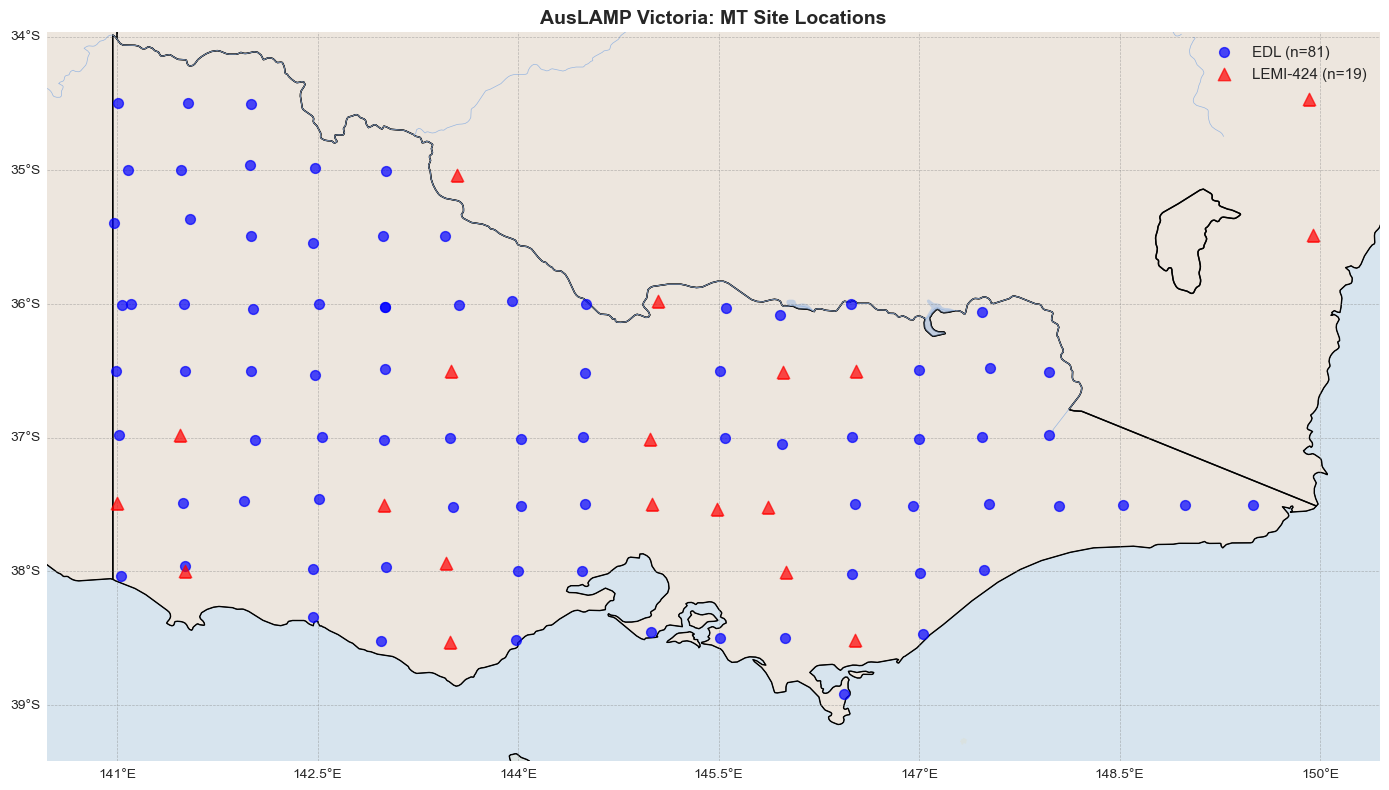

*Figure 1. Map showing 100 MT sites in Victoria. Blue circles: EDL sites (n=81). Red triangles: LEMI-424 sites (n=19). State boundaries shown in black. Background shows terrain, coastlines, and rivers.*

In [10]:
# Create map with Cartopy
if len(sites_with_coords) > 0:
    fig = plt.figure(figsize=(14, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Set extent to Victoria
    lat_min = sites_with_coords['latitude'].min() - 0.5
    lat_max = sites_with_coords['latitude'].max() + 0.5
    lon_min = sites_with_coords['longitude'].min() - 0.5
    lon_max = sites_with_coords['longitude'].max() + 0.5
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    # Add features
    ax.add_feature(cfeature.LAND, facecolor='wheat', alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=1.0)  # Add state boundaries
    ax.add_feature(cfeature.LAKES, alpha=0.5)
    ax.add_feature(cfeature.RIVERS, linewidth=0.5)

    # Plot EDL sites
    edl_sites_map = sites_with_coords[sites_with_coords['instrument'] == 'EDL']
    if len(edl_sites_map) > 0:
        ax.scatter(edl_sites_map['longitude'], edl_sites_map['latitude'],
                   c='blue', marker='o', s=50, alpha=0.7, 
                   label=f'EDL (n={len(edl_sites_map)})',
                   transform=ccrs.PlateCarree(), zorder=5)

    # Plot LEMI-424 sites
    lemi_sites_map = sites_with_coords[sites_with_coords['instrument'] == 'LEMI-424']
    if len(lemi_sites_map) > 0:
        ax.scatter(lemi_sites_map['longitude'], lemi_sites_map['latitude'],
                   c='red', marker='^', s=80, alpha=0.7,
                   label=f'LEMI-424 (n={len(lemi_sites_map)})',
                   transform=ccrs.PlateCarree(), zorder=5)

    # Add gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    ax.legend(loc='upper right', fontsize=11)
    ax.set_title('AusLAMP Victoria: MT Site Locations', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    caption(f"Figure 1. Map showing {len(sites_with_coords)} MT sites in Victoria. "
            f"Blue circles: EDL sites (n={len(edl_sites_map)}). "
            f"Red triangles: LEMI-424 sites (n={len(lemi_sites_map)}). "
            f"State boundaries shown in black. Background shows terrain, coastlines, and rivers.")
else:
    print("Skipping map: No sites with coordinates available")
    print("Run notebook 02 first to generate QA/QC CSV with EDL coordinates")

## Recording Timelines for Remote Reference Selection

In [11]:
# Recording Duration Statistics
print("Recording Duration Statistics:\n")

for instrument in ['EDL', 'LEMI-424']:
    subset = combined_metadata[combined_metadata['instrument'] == instrument]
    if len(subset) > 0:
        print(f"{instrument}:")
        print(f"  Number of sites: {len(subset)}")
        print(f"  Mean duration: {subset['duration_days'].mean():.1f} days")
        print(f"  Min duration: {subset['duration_days'].min():.1f} days")
        print(f"  Max duration: {subset['duration_days'].max():.1f} days")
        print(f"  Total recording time: {subset['duration_days'].sum():.1f} days")
        print()

Recording Duration Statistics:

EDL:
  Number of sites: 81
  Mean duration: 25.2 days
  Min duration: 9.3 days
  Max duration: 56.4 days
  Total recording time: 2043.6 days

LEMI-424:
  Number of sites: 19
  Mean duration: 55.4 days
  Min duration: 32.7 days
  Max duration: 210.0 days
  Total recording time: 1052.7 days



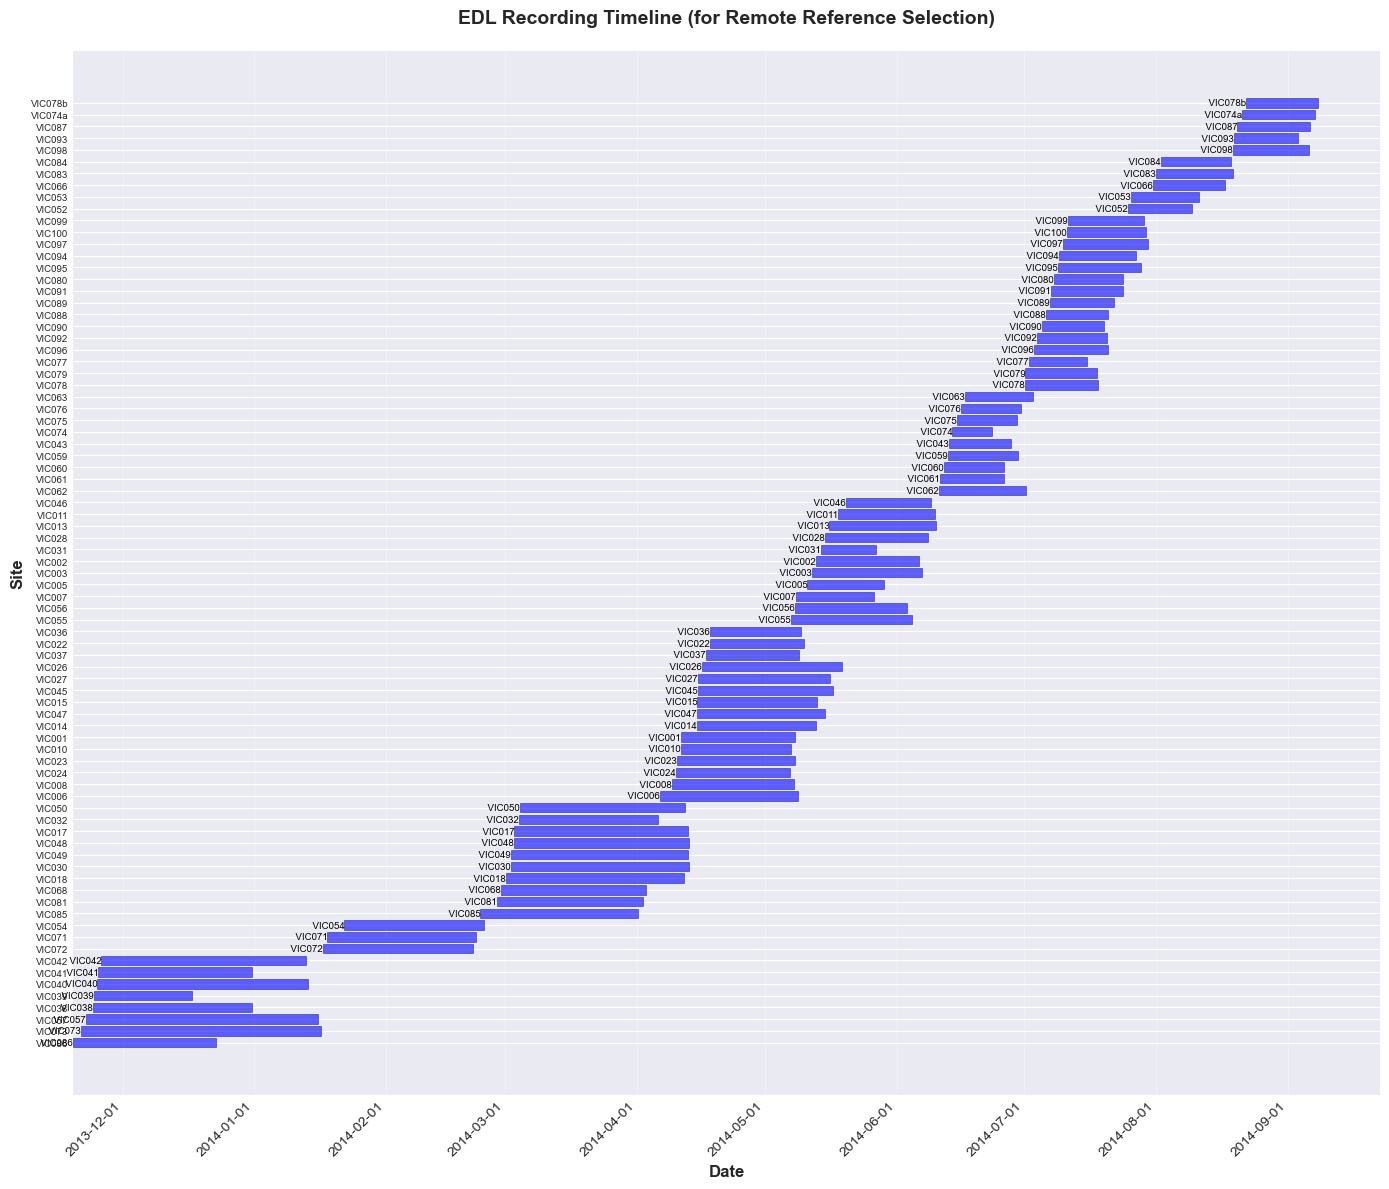

*Figure 2. EDL recording timeline showing 81 sites sorted by start date. Horizontal bars represent recording periods. Overlapping recordings can be used as remote references for magnetotelluric processing.*

In [12]:
# EDL Recording Timeline
edl_data = combined_metadata[combined_metadata['instrument'] == 'EDL'].copy()
edl_data = edl_data.sort_values('start_time')

fig, ax = plt.subplots(figsize=(14, 12))

for idx, (_, row) in enumerate(edl_data.iterrows()):
    ax.barh(idx, 
            (row['end_time'] - row['start_time']).total_seconds() / 86400,
            left=row['start_time'], 
            height=0.8, 
            color='blue', 
            alpha=0.6,
            edgecolor='darkblue',
            linewidth=0.5)
    
    # Add site name label
    ax.text(row['start_time'], idx, f"  {row['site_id']}", 
            va='center', ha='right', fontsize=7, color='black')

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Site', fontsize=12, fontweight='bold')
ax.set_title('EDL Recording Timeline (for Remote Reference Selection)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='x')
ax.set_yticks(range(len(edl_data)))
ax.set_yticklabels(edl_data['site_id'].values, fontsize=7)

# Format x-axis to show dates nicely
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

caption(f"Figure 2. EDL recording timeline showing {len(edl_data)} sites sorted by start date. "
        f"Horizontal bars represent recording periods. Overlapping recordings can be used "
        f"as remote references for magnetotelluric processing.")

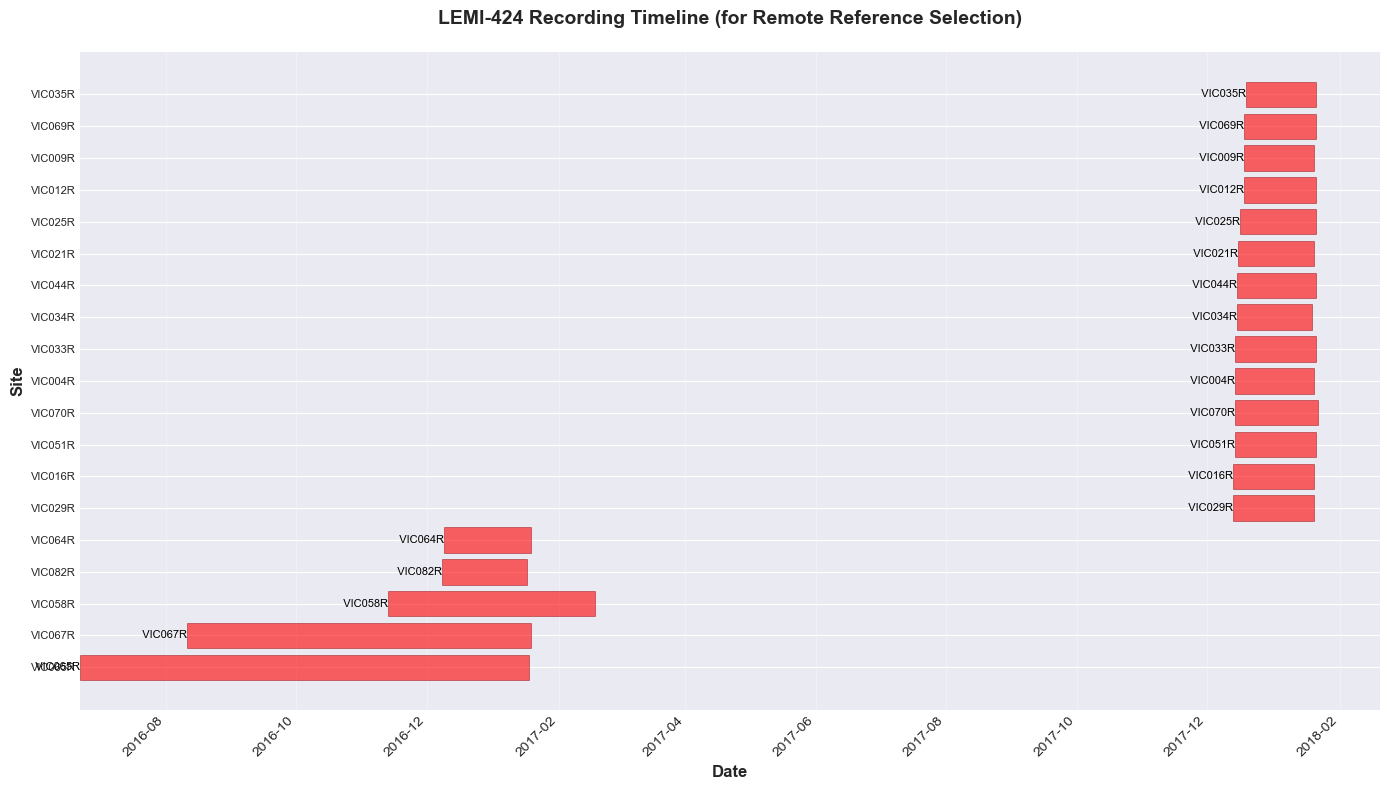

*Figure 3. LEMI-424 recording timeline showing 19 sites sorted by start date. Horizontal bars represent recording periods. These sites recorded 2016-2017, separate from EDL deployments (2013-2014). Note VIC065R and VIC067R have significantly longer recording durations suitable for use as remote reference stations.*

In [13]:
# LEMI-424 Recording Timeline
lemi_data = combined_metadata[combined_metadata['instrument'] == 'LEMI-424'].copy()
lemi_data = lemi_data.sort_values('start_time')

fig, ax = plt.subplots(figsize=(14, 8))

for idx, (_, row) in enumerate(lemi_data.iterrows()):
    ax.barh(idx, 
            (row['end_time'] - row['start_time']).total_seconds() / 86400,
            left=row['start_time'], 
            height=0.8, 
            color='red', 
            alpha=0.6,
            edgecolor='darkred',
            linewidth=0.5)
    
    # Add site name label
    ax.text(row['start_time'], idx, f"  {row['site_id']}", 
            va='center', ha='right', fontsize=8, color='black')

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Site', fontsize=12, fontweight='bold')
ax.set_title('LEMI-424 Recording Timeline (for Remote Reference Selection)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='x')
ax.set_yticks(range(len(lemi_data)))
ax.set_yticklabels(lemi_data['site_id'].values, fontsize=8)

# Format x-axis to show dates nicely
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

caption(f"Figure 3. LEMI-424 recording timeline showing {len(lemi_data)} sites sorted by start date. "
        f"Horizontal bars represent recording periods. These sites recorded 2016-2017, "
        f"separate from EDL deployments (2013-2014). Note VIC065R and VIC067R have significantly "
        f"longer recording durations suitable for use as remote reference stations.")

## Load and Calculate Statistics for All Sites

For each site, load a sample of data and calculate mean and std for BX, BY, BZ, EX, EY.

In [14]:
# Function to load and calculate statistics from EDL site
def get_edl_statistics(site_dir, n_samples=36000):
    """Load first n_samples from EDL site and calculate statistics."""
    # Get all .dat files
    dat_files = sorted(list(site_dir.glob('*.dat')))
    
    if len(dat_files) == 0:
        return None
    
    # Load first file (or until we have n_samples)
    df_list = []
    total_samples = 0
    
    for dat_file in dat_files:
        try:
            df = pd.read_csv(dat_file, sep=' ')
            df_list.append(df)
            total_samples += len(df)
            
            if total_samples >= n_samples:
                break
        except Exception as e:
            continue
    
    if len(df_list) == 0:
        return None
    
    df_combined = pd.concat(df_list, ignore_index=True)
    df_combined = df_combined.iloc[:n_samples]  # Truncate to n_samples
    
    # Calculate statistics
    # EDL columns: DateTime, BX, BY, BZ, EX, EY (uppercase!)
    # Units: nT for B, µV for E (raw ADC values)
    stats = {
        'bx_mean': df_combined['BX'].mean(),
        'by_mean': df_combined['BY'].mean(),
        'bz_mean': df_combined['BZ'].mean(),
        'ex_mean': df_combined['EX'].mean(),
        'ey_mean': df_combined['EY'].mean(),
        'bx_std': df_combined['BX'].std(),
        'by_std': df_combined['BY'].std(),
        'bz_std': df_combined['BZ'].std(),
        'ex_std': df_combined['EX'].std(),
        'ey_std': df_combined['EY'].std(),
    }
    
    return stats


# Function to load and calculate statistics from LEMI-424 site
def get_lemi_statistics(site_dir, n_samples=36000):
    """Load first n_samples from LEMI-424 site and calculate statistics."""
    # LEMI files are in DATA#### subdirectories
    data_dirs = sorted([d for d in site_dir.glob('DATA*') if d.is_dir()])
    
    # Collect all .TXT files from all DATA directories
    txt_files = []
    for data_dir in data_dirs:
        txt_files.extend(list(data_dir.glob('*.txt')))
        txt_files.extend(list(data_dir.glob('*.TXT')))
    
    txt_files = sorted(txt_files)
    
    if len(txt_files) == 0:
        return None
    
    # Load first file (or until we have n_samples)
    df_list = []
    total_samples = 0
    
    for txt_file in txt_files:
        reader = LEMI424Reader(txt_file)
        df = reader.read()
        
        if df is None:
            continue
        
        df_list.append(df)
        total_samples += len(df)
        
        if total_samples >= n_samples:
            break
    
    if len(df_list) == 0:
        return None
    
    df_combined = pd.concat(df_list)
    df_combined = df_combined.iloc[:n_samples]  # Truncate to n_samples
    
    # Calculate statistics (Ex, Ey are electric channels)
    stats = {
        'bx_mean': df_combined['Bx'].mean(),
        'by_mean': df_combined['By'].mean(),
        'bz_mean': df_combined['Bz'].mean(),
        'ex_mean': df_combined['Ex'].mean(),
        'ey_mean': df_combined['Ey'].mean(),
        'bx_std': df_combined['Bx'].std(),
        'by_std': df_combined['By'].std(),
        'bz_std': df_combined['Bz'].std(),
        'ex_std': df_combined['Ex'].std(),
        'ey_std': df_combined['Ey'].std(),
    }
    
    return stats

In [15]:
# Calculate statistics for all sites
import time

print("Calculating statistics for all sites...\n")

stats_list = []

# EDL sites
for site_dir in edl_sites:
    site_id = site_dir.name
    print(f"Processing {site_id}...", end=' ')
    
    try:
        stats = get_edl_statistics(site_dir)
        if stats:
            stats['site_id'] = site_id
            stats['instrument'] = 'EDL'
            stats_list.append(stats)
            print("✓")
        else:
            print("✗ No data")
    except Exception as e:
        print(f"✗ Error: {e}")

# LEMI-424 sites
for site_dir in lemi_sites:
    site_id = site_dir.name
    print(f"Processing {site_id}...", end=' ')
    
    try:
        stats = get_lemi_statistics(site_dir)
        if stats:
            stats['site_id'] = site_id
            stats['instrument'] = 'LEMI-424'
            stats_list.append(stats)
            print("✓")
        else:
            print("✗ No data")
    except Exception as e:
        print(f"✗ Error: {e}")

stats_df = pd.DataFrame(stats_list)
print(f"\nCalculated statistics for {len(stats_df)} sites")

Calculating statistics for all sites...

Processing VIC001... ✓
Processing VIC002... ✓
Processing VIC003... ✓
Processing VIC005... ✓
Processing VIC006... ✓
Processing VIC007... ✓
Processing VIC008... ✓
Processing VIC010... ✓
Processing VIC011... ✓
Processing VIC013... ✓
Processing VIC014... ✓
Processing VIC015... ✓
Processing VIC017... ✓
Processing VIC018... ✓
Processing VIC022... ✓
Processing VIC023... ✓
Processing VIC024... ✓
Processing VIC026... ✓
Processing VIC027... ✓
Processing VIC028... ✓
Processing VIC030... ✓
Processing VIC031... ✓
Processing VIC032... ✓
Processing VIC036... ✓
Processing VIC037... ✓
Processing VIC038... ✓
Processing VIC039... ✓
Processing VIC040... ✓
Processing VIC041... ✓
Processing VIC042... ✓
Processing VIC043... ✓
Processing VIC045... ✓
Processing VIC046... ✓
Processing VIC047... ✓
Processing VIC048... ✓
Processing VIC049... ✓
Processing VIC050... ✓
Processing VIC052... ✓
Processing VIC053... ✓
Processing VIC054... ✓
Processing VIC055... ✓
Processing VIC05

In [16]:
# Merge statistics with metadata
full_df = combined_metadata.merge(stats_df, on=['site_id', 'instrument'], how='left')

print(f"Combined dataframe: {len(full_df)} sites")
full_df.head(20)

Combined dataframe: 100 sites


,site_id,instrument,latitude,longitude,elevation,start_time,end_time,duration_days,n_files,bx_mean,by_mean,bz_mean,ex_mean,ey_mean,bx_std,by_std,bz_std,ex_std,ey_std
0,VIC001,EDL,-38.92,146.44,90.00,2014-04-11 06:00:00,2014-05-08 00:59:59.900,26.79,28,22100.48,-1562.53,-53535.11,7543.78,-103496.90,10.33,14.44,205.51,5771.64,3368.58
1,VIC002,EDL,-38.34,142.47,33.00,2014-05-13 00:00:00,2014-06-06 03:59:59.900,24.17,25,20516.75,3352.00,-53108.96,-390935.60,-154655.99,0.68,1.75,9.37,13073.40,491.38
2,VIC003,EDL,-38.52,142.97,50.00,2014-05-12 03:00:00,2014-06-06 22:59:59.900,25.83,26,20926.19,-998.26,-56537.31,-600068.64,62865.49,1.73,3.82,2.28,795.33,962.03
3,VIC005,EDL,-38.51,143.99,184.00,2014-05-11 00:00:00,2014-05-28 22:59:59.900,17.96,18,22269.53,1843.78,-55754.41,271222.22,497959.43,18.18,29.75,52.76,3805.19,5479.18
4,VIC006,EDL,-38.45,145.00,120.00,2014-04-06 07:00:00,2014-05-08 21:59:59.900,32.62,33,22421.81,2583.72,-55587.51,84847.95,151770.08,1.87,0.92,2.32,810.98,3080.08
5,VIC007,EDL,-38.50,145.51,NaN,2014-05-08 08:00:00,2014-05-26 17:59:59.900,18.42,19,19365.24,-2533.98,-56519.89,151159.98,-362480.56,11.80,10.57,3.69,3451.92,4454.19
6,VIC008,EDL,-38.50,146.00,46.00,2014-04-09 02:00:00,2014-05-07 21:59:59.900,28.83,29,20527.66,785.18,-56041.27,109578.59,307126.51,2.00,7.83,29.28,2171.74,1854.85
7,VIC010,EDL,-38.47,147.03,3.00,2014-04-11 05:00:00,2014-05-07 01:59:59.900,25.87,27,-23431.99,-602.14,-55248.33,77871.87,25467.32,15.81,19.68,22.33,8541.33,8600.81
8,VIC011,EDL,-38.03,141.03,30.00,2014-05-18 08:00:00,2014-06-09 21:59:59.900,22.58,23,21962.04,805.15,-55939.79,-721879.36,16030.98,0.73,0.97,0.84,3608.36,968.34
9,VIC013,EDL,-37.96,141.51,156.00,2014-05-16 04:00:00,2014-06-10 04:25:59.900,25.02,26,23022.93,-2036.01,-52460.75,196747.33,-299497.20,7.43,2.70,28.41,184.31,1354.54


## Statistical Plots: Mean Field Values

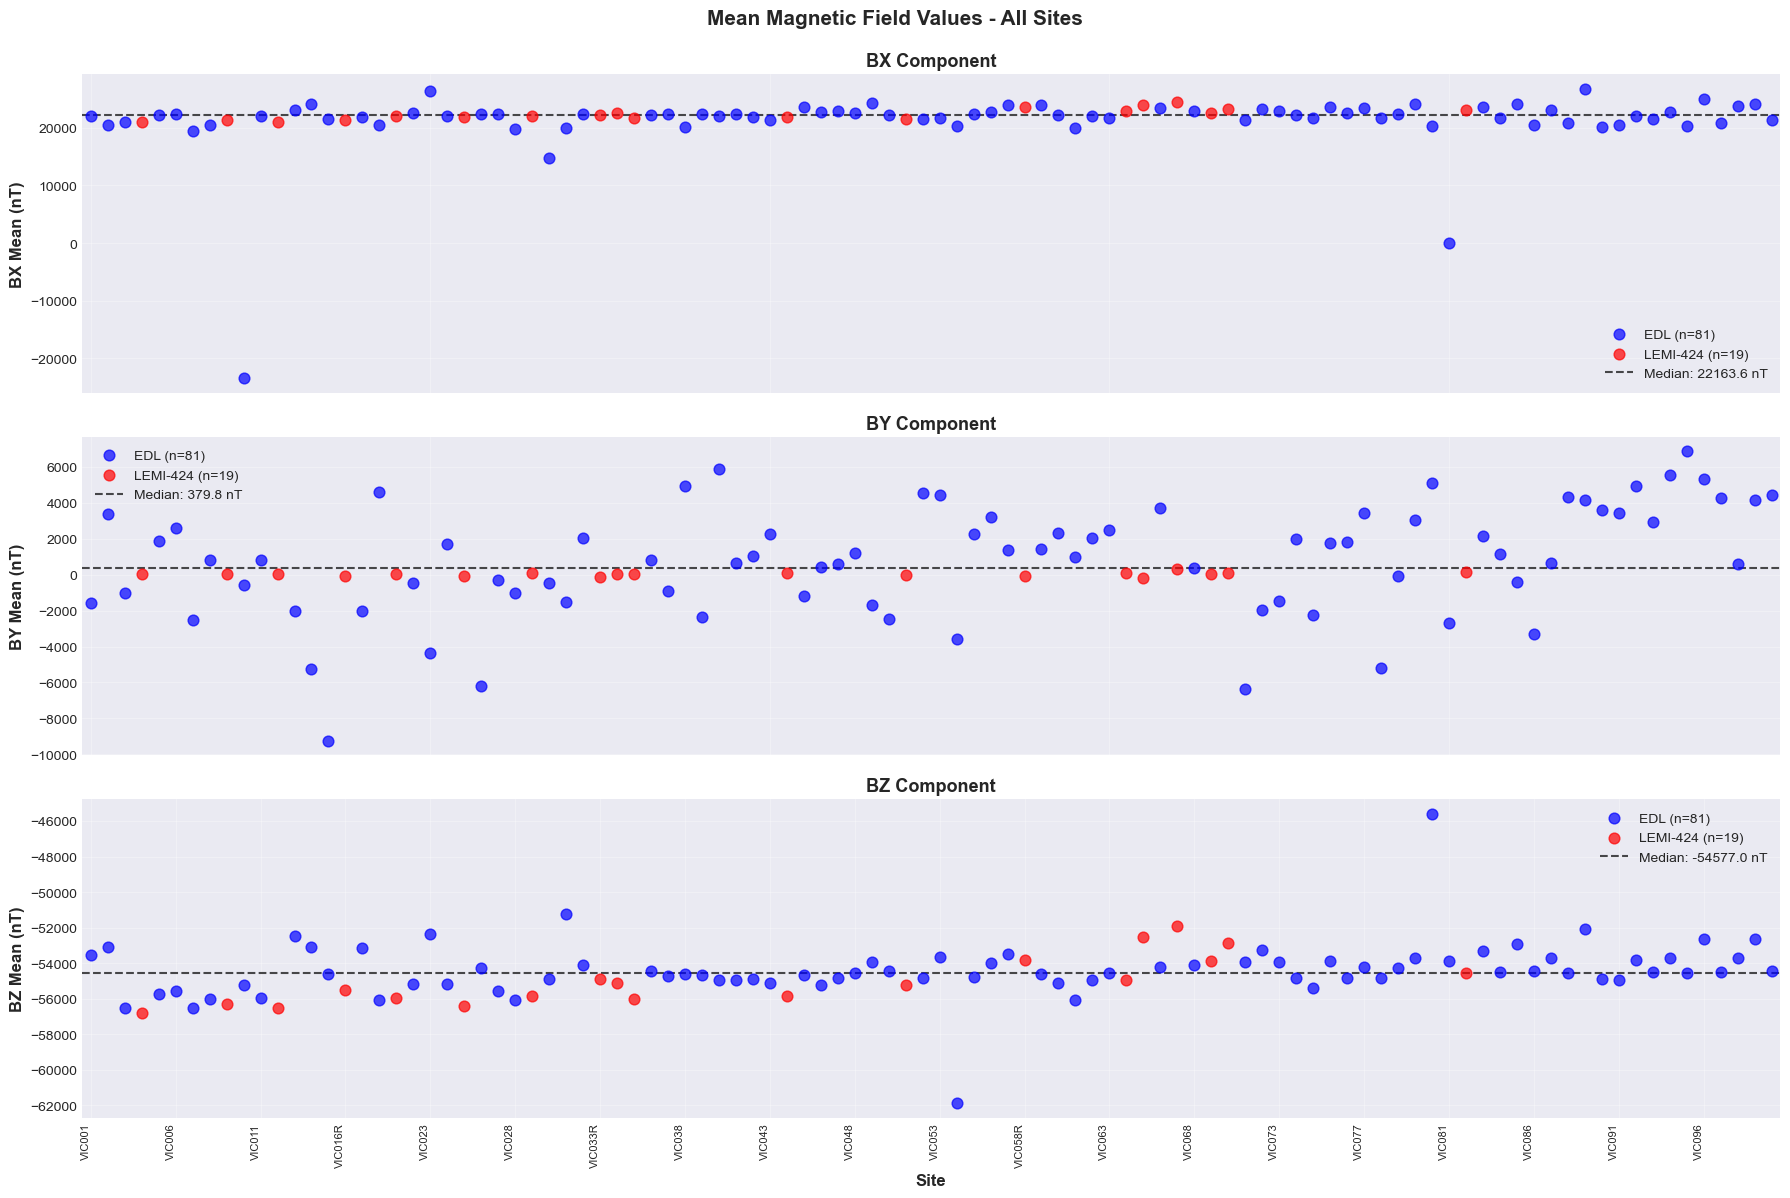

*Figure 4. Mean magnetic field values for all 100 sites (first hour of recording). Blue: EDL sites (n=81). Red: LEMI-424 sites (n=19). Black dashed line shows overall median. Sites sorted alphabetically by ID. Vertically stacked layout allows direct comparison across components with aligned x-axis.*

In [17]:
# Plot mean values for magnetic channels
fig, axes = plt.subplots(3, 1, figsize=(18, 12))

channels = ['bx', 'by', 'bz']
colors = {'EDL': 'blue', 'LEMI-424': 'red'}

for i, ch in enumerate(channels):
    ax = axes[i]
    
    # Get all sites with data for this channel
    sites_with_data = full_df.dropna(subset=[f'{ch}_mean']).copy()
    sites_with_data = sites_with_data.sort_values('site_id')
    
    # Plot by instrument
    for instrument in ['EDL', 'LEMI-424']:
        subset = sites_with_data[sites_with_data['instrument'] == instrument]
        
        if len(subset) > 0:
            x_pos = range(len(sites_with_data))
            # Get positions for this instrument's sites
            mask = sites_with_data['instrument'] == instrument
            x_instrument = [i for i, m in enumerate(mask) if m]
            y = subset[f'{ch}_mean'].values
            ax.scatter(x_instrument, y, c=colors[instrument], alpha=0.7, s=60, 
                      label=f'{instrument} (n={len(subset)})', zorder=3)
    
    # Add median line
    all_values = sites_with_data[f'{ch}_mean']
    if len(all_values) > 0:
        median_val = all_values.median()
        ax.axhline(median_val, color='black', linestyle='--', linewidth=1.5, alpha=0.7,
                  label=f'Median: {median_val:.1f} nT', zorder=2)
    
    ax.set_ylabel(f'{ch.upper()} Mean (nT)', fontsize=12, fontweight='bold')
    ax.set_title(f'{ch.upper()} Component', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3, zorder=1)
    
    # Set x-axis ticks with site names (only on bottom plot)
    if i == len(channels) - 1:  # Bottom plot
        ax.set_xlabel('Site', fontsize=12, fontweight='bold')
        # Show ALL site names on x-axis
        tick_positions = range(len(sites_with_data))
        tick_labels = sites_with_data['site_id'].values
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=90, fontsize=8, ha='right')
    else:
        ax.set_xticklabels([])  # Hide labels on upper plots
    
    # Always set xlim for alignment
    ax.set_xlim(-0.5, len(sites_with_data) - 0.5)

plt.suptitle('Mean Magnetic Field Values - All Sites', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

caption(f"Figure 4. Mean magnetic field values for all {len(sites_with_data)} sites (first hour of recording). "
        f"Blue: EDL sites (n={len(sites_with_data[sites_with_data['instrument']=='EDL'])}). "
        f"Red: LEMI-424 sites (n={len(sites_with_data[sites_with_data['instrument']=='LEMI-424'])}). "
        f"Black dashed line shows overall median. Sites sorted alphabetically by ID. "
        f"Vertically stacked layout allows direct comparison across components with aligned x-axis.")

In [18]:
# NOTE: This cell is a duplicate of cell-25 and can be deleted
# It was created during notebook development and is no longer needed
# The correct plot with improved formatting is in cell-25
pass

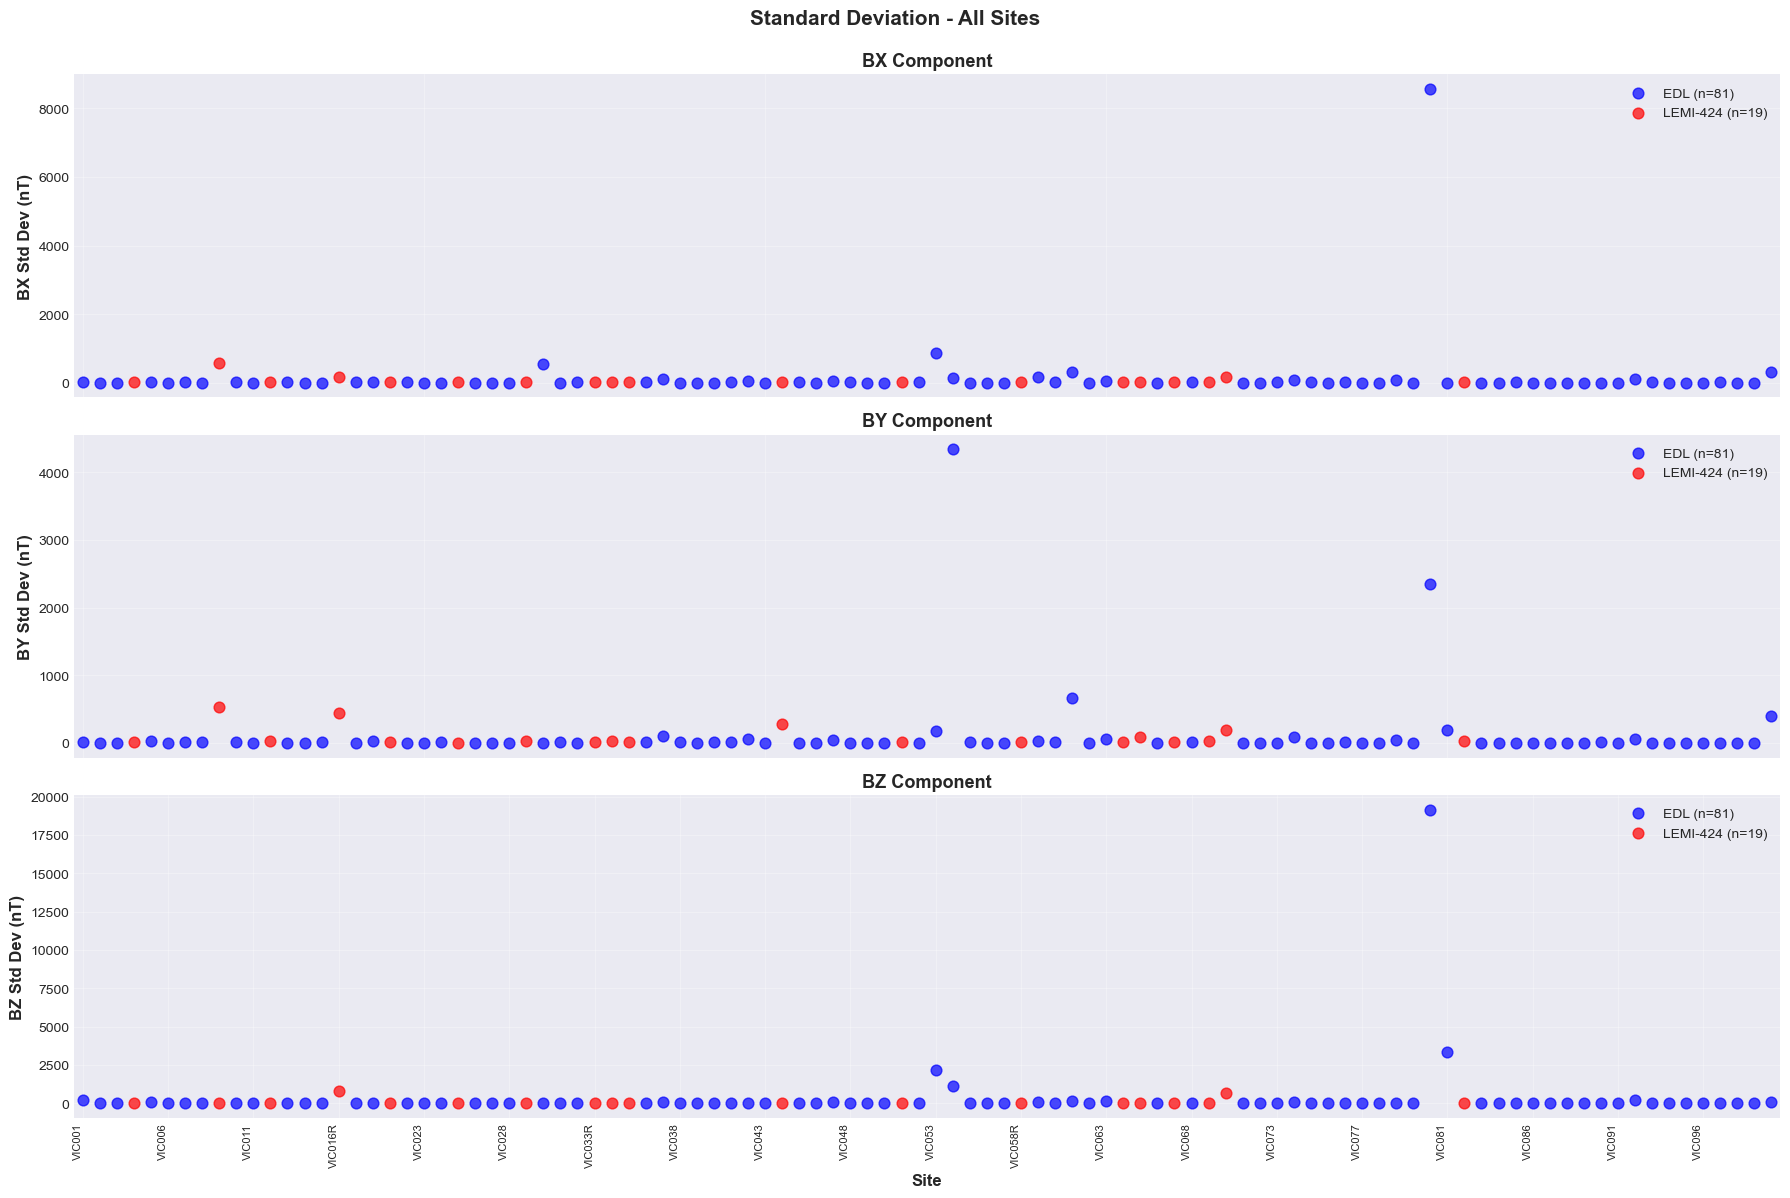

*Figure 5. Standard deviation of magnetic field components for all 100 sites. Shows natural field variations and instrument noise levels. Blue: EDL (n=81). Red: LEMI-424 (n=19). Vertically stacked layout allows direct comparison with aligned x-axis.*

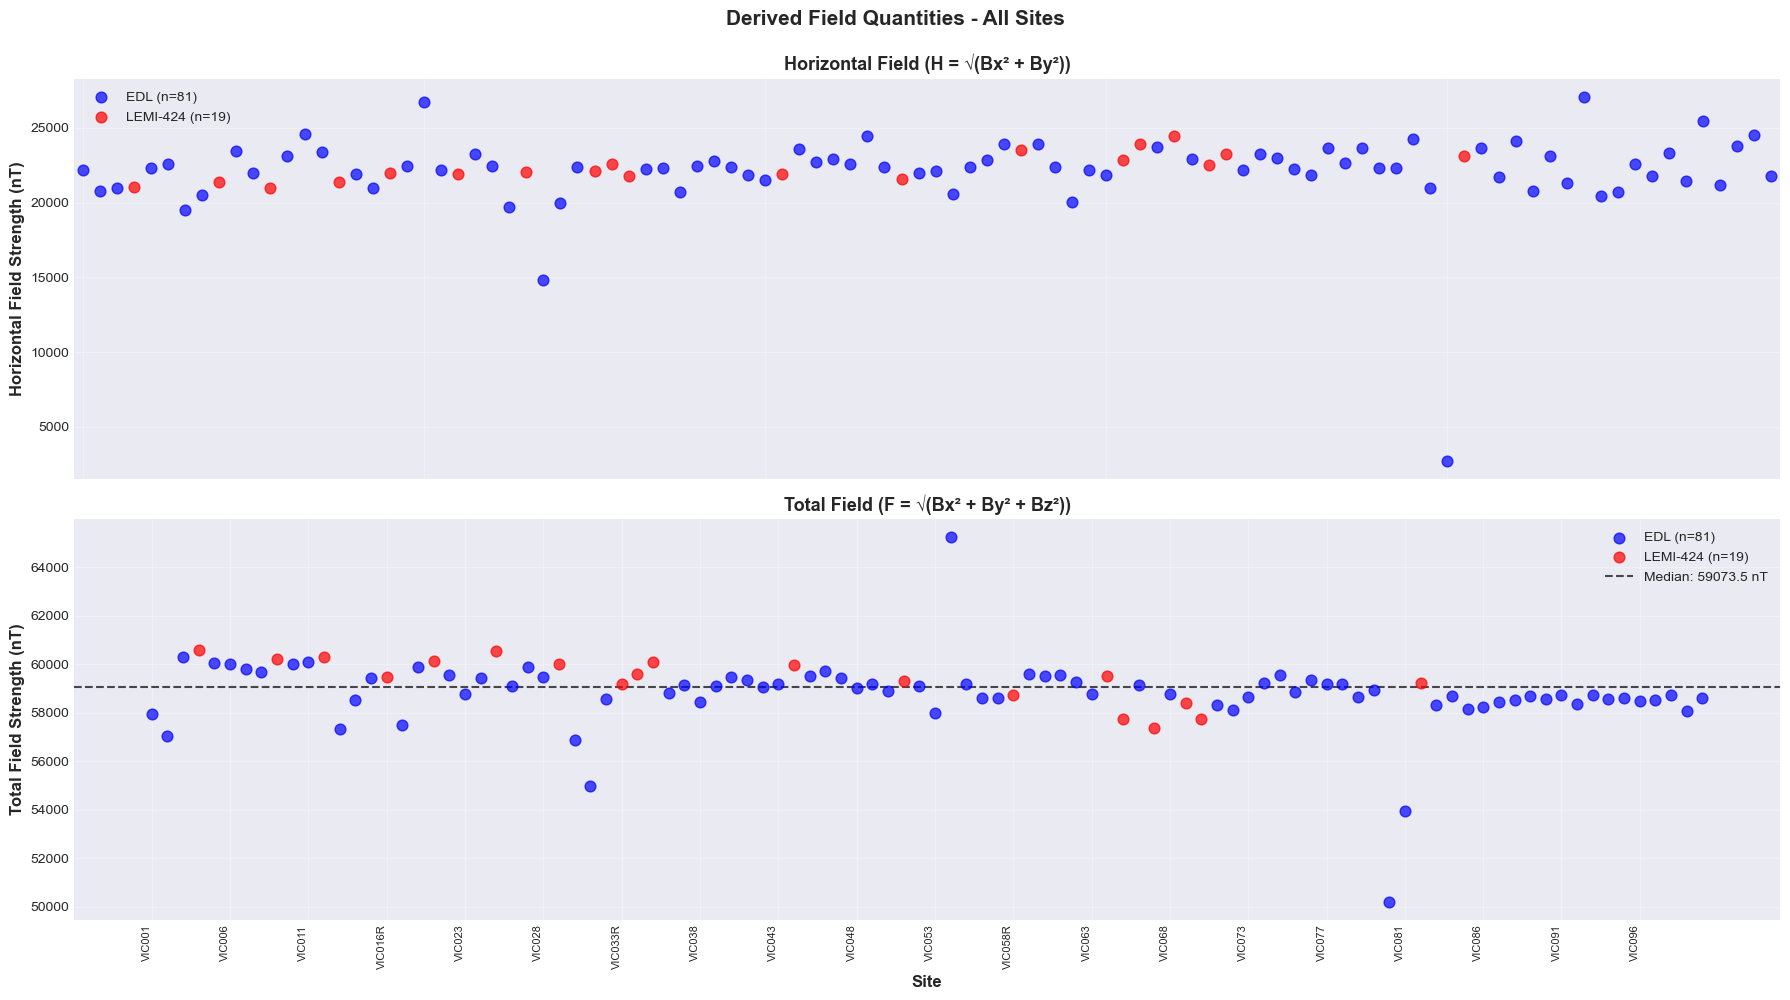

*Figure 6. Horizontal field strength (top) and total field strength (bottom) for all 100 sites. Blue: EDL (n=81). Red: LEMI-424 (n=19). Black dashed line shows median total field. Vertically stacked layout allows direct comparison with aligned x-axis.*

In [19]:
# Plot standard deviations
fig, axes = plt.subplots(3, 1, figsize=(18, 12))

channels = ['bx', 'by', 'bz']
colors = {'EDL': 'blue', 'LEMI-424': 'red'}

for i, ch in enumerate(channels):
    ax = axes[i]
    
    # Get all sites with data for this channel
    sites_with_data = full_df.dropna(subset=[f'{ch}_std']).copy()
    sites_with_data = sites_with_data.sort_values('site_id')
    
    # Plot by instrument
    for instrument in ['EDL', 'LEMI-424']:
        subset = sites_with_data[sites_with_data['instrument'] == instrument]
        
        if len(subset) > 0:
            # Get positions for this instrument's sites
            mask = sites_with_data['instrument'] == instrument
            x_instrument = [i for i, m in enumerate(mask) if m]
            y = subset[f'{ch}_std'].values
            ax.scatter(x_instrument, y, c=colors[instrument], alpha=0.7, s=60,
                      label=f'{instrument} (n={len(subset)})', zorder=3)
    
    ax.set_ylabel(f'{ch.upper()} Std Dev (nT)', fontsize=12, fontweight='bold')
    ax.set_title(f'{ch.upper()} Component', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3, zorder=1)
    
    # Set x-axis ticks with site names (only on bottom plot)
    if i == len(channels) - 1:  # Bottom plot
        ax.set_xlabel('Site', fontsize=12, fontweight='bold')
        # Show ALL site names
        tick_positions = range(len(sites_with_data))
        tick_labels = sites_with_data['site_id'].values
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=90, fontsize=8, ha='right')
    else:
        ax.set_xticklabels([])
    
    # Always set xlim for alignment
    ax.set_xlim(-0.5, len(sites_with_data) - 0.5)

plt.suptitle('Standard Deviation - All Sites', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

caption(f"Figure 5. Standard deviation of magnetic field components for all {len(sites_with_data)} sites. "
        f"Shows natural field variations and instrument noise levels. "
        f"Blue: EDL (n={len(sites_with_data[sites_with_data['instrument']=='EDL'])}). "
        f"Red: LEMI-424 (n={len(sites_with_data[sites_with_data['instrument']=='LEMI-424'])}). "
        f"Vertically stacked layout allows direct comparison with aligned x-axis.")

# Calculate derived field quantities
full_df['h_field'] = np.sqrt(full_df['bx_mean']**2 + full_df['by_mean']**2)  # Horizontal field
full_df['total_field'] = np.sqrt(full_df['bx_mean']**2 + full_df['by_mean']**2 + full_df['bz_mean']**2)  # Total field

# Plot horizontal and total field strength
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Horizontal field
ax = axes[0]
sites_h = full_df.dropna(subset=['h_field']).copy()
sites_h = sites_h.sort_values('site_id')

for instrument in ['EDL', 'LEMI-424']:
    subset = sites_h[sites_h['instrument'] == instrument]
    
    if len(subset) > 0:
        mask = sites_h['instrument'] == instrument
        x_instrument = [i for i, m in enumerate(mask) if m]
        y = subset['h_field'].values
        ax.scatter(x_instrument, y, c=colors[instrument], alpha=0.7, s=60,
                  label=f'{instrument} (n={len(subset)})', zorder=3)

ax.set_ylabel('Horizontal Field Strength (nT)', fontsize=12, fontweight='bold')
ax.set_title('Horizontal Field (H = √(Bx² + By²))', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, zorder=1)
ax.set_xticklabels([])  # Hide labels on top plot
ax.set_xlim(-0.5, len(sites_h) - 0.5)

# Total field
ax = axes[1]
sites_f = full_df.dropna(subset=['total_field']).copy()
sites_f = sites_f.sort_values('site_id')

for instrument in ['EDL', 'LEMI-424']:
    subset = sites_f[sites_f['instrument'] == instrument]
    
    if len(subset) > 0:
        mask = sites_f['instrument'] == instrument
        x_instrument = [i for i, m in enumerate(mask) if m]
        y = subset['total_field'].values
        ax.scatter(x_instrument, y, c=colors[instrument], alpha=0.7, s=60,
                  label=f'{instrument} (n={len(subset)})', zorder=3)

# Add median line for total field
median_total = sites_f['total_field'].median()
ax.axhline(median_total, color='black', linestyle='--', linewidth=1.5, alpha=0.7,
          label=f'Median: {median_total:.1f} nT', zorder=2)

ax.set_ylabel('Total Field Strength (nT)', fontsize=12, fontweight='bold')
ax.set_xlabel('Site', fontsize=12, fontweight='bold')
ax.set_title('Total Field (F = √(Bx² + By² + Bz²))', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, zorder=1)

# Set x-axis ticks with site names

# Set x-axis limits for alignment
ax.set_xlim(-0.5, len(sites_f) - 0.5)

# Set x-axis ticks with ALL site names
tick_positions = range(len(sites_f))
tick_labels = sites_f['site_id'].values
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, fontsize=8, ha='right')

plt.suptitle('Derived Field Quantities - All Sites', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

caption(f"Figure 6. Horizontal field strength (top) and total field strength (bottom) for all {len(sites_f)} sites. "
        f"Blue: EDL (n={len(sites_f[sites_f['instrument']=='EDL'])}). "
        f"Red: LEMI-424 (n={len(sites_f[sites_f['instrument']=='LEMI-424'])}). "
        f"Black dashed line shows median total field. "
        f"Vertically stacked layout allows direct comparison with aligned x-axis.")

## Comparison with AGRF Model Field

In [20]:
# Calculate AGRF25 model field values using the GA AGRF25 wrapper
from agrf_wrapper import compute_agrf25
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# AGRF directory - use absolute path
agrf_dir = Path(r'D:\BK_AusLAMP_GA\data\eCat_150056_AGRF25')

print(f"Using AGRF25 from: {agrf_dir}")
print(f"AGRF25 valid: 2020-2030 (optimized for 2025-2030)")
print()

# First, ensure we have derived field quantities from earlier cell
if 'h_field' not in full_df.columns or 'total_field' not in full_df.columns:
    print("Calculating derived field quantities (H and F)...")
    full_df['h_field'] = np.sqrt(full_df['bx_mean']**2 + full_df['by_mean']**2)  # Horizontal field
    full_df['total_field'] = np.sqrt(full_df['bx_mean']**2 + full_df['by_mean']**2 + full_df['bz_mean']**2)  # Total field
    print(f"  H field: {full_df['h_field'].notna().sum()} sites with data")
    print(f"  F field: {full_df['total_field'].notna().sum()} sites with data")
    print()

# Create EXTENDED grid for AGRF model - ~200km beyond Victoria boundaries
# Victoria roughly: lat -39 to -34, lon 141 to 150
# Add ~2 degrees (~200km) on each side for smooth coverage
lat_grid = np.linspace(-41, -32, 30)  # Extended grid, finer resolution
lon_grid = np.linspace(139, 152, 40)

print(f"Calculating AGRF25 field on {len(lat_grid)}x{len(lon_grid)} grid (extended ~200km beyond Victoria)...")
agrf_total_grid = np.zeros((len(lat_grid), len(lon_grid)))
agrf_h_grid = np.zeros((len(lat_grid), len(lon_grid)))

# Use average year for the datasets (EDL: 2014, LEMI: 2016-2017)
# AGRF25 is valid back to 2020, so we'll use 2020 as the earliest valid year
year = 2020.0

for i, lat in enumerate(lat_grid):
    for j, lon in enumerate(lon_grid):
        try:
            result = compute_agrf25(lat, lon, alt_km=0.1, year=year, agrf_dir=agrf_dir)
            agrf_total_grid[i, j] = result['F']  # Total field
            agrf_h_grid[i, j] = result['H']      # Horizontal field
        except Exception as e:
            if i == 0 and j == 0:  # Only print first error
                print(f"Error at ({lat:.2f}, {lon:.2f}): {e}")
                print("Continuing with remaining grid points...")
            agrf_total_grid[i, j] = np.nan
            agrf_h_grid[i, j] = np.nan

print(f"AGRF25 Total Field range: {np.nanmin(agrf_total_grid):.0f} - {np.nanmax(agrf_total_grid):.0f} nT")
print(f"AGRF25 Horizontal Field range: {np.nanmin(agrf_h_grid):.0f} - {np.nanmax(agrf_h_grid):.0f} nT")

# Create meshgrid for plotting
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# Calculate expected AGRF values at each site location
print("\nCalculating AGRF25 at site locations...")
sites_for_map = full_df.dropna(subset=['latitude', 'longitude', 'total_field', 'h_field']).copy()

agrf_total_list = []
agrf_h_list = []

for idx, row in sites_for_map.iterrows():
    try:
        result = compute_agrf25(
            row['latitude'], 
            row['longitude'], 
            alt_km=row['elevation']/1000 if pd.notna(row['elevation']) else 0.1,
            year=year,
            agrf_dir=agrf_dir
        )
        agrf_total_list.append(result['F'])
        agrf_h_list.append(result['H'])
    except Exception as e:
        print(f"Error at {row['site_id']}: {e}")
        agrf_total_list.append(np.nan)
        agrf_h_list.append(np.nan)

sites_for_map['agrf_total'] = agrf_total_list
sites_for_map['agrf_h'] = agrf_h_list

# Calculate differences (residuals)
sites_for_map['total_residual'] = sites_for_map['total_field'] - sites_for_map['agrf_total']
sites_for_map['h_residual'] = sites_for_map['h_field'] - sites_for_map['agrf_h']

# Remove sites with NaN residuals
sites_for_map = sites_for_map.dropna(subset=['total_residual', 'h_residual'])

print(f"\nAGRF25 calculated for {len(sites_for_map)} sites")
print(f"\nSite measurements vs AGRF25:")
print(f"Total field residuals: {sites_for_map['total_residual'].min():.0f} to {sites_for_map['total_residual'].max():.0f} nT")
print(f"Horizontal field residuals: {sites_for_map['h_residual'].min():.0f} to {sites_for_map['h_residual'].max():.0f} nT")
print(f"Mean total field residual: {sites_for_map['total_residual'].mean():.0f} nT")
print(f"Mean horizontal field residual: {sites_for_map['h_residual'].mean():.0f} nT")

Using AGRF25 from: D:\BK_AusLAMP_GA\2026_Geomagnetic_AusLAMP\data\eCat_150056_AGRF25
AGRF25 valid: 2020-2030 (optimized for 2025-2030)

Calculating AGRF25 field on 30x40 grid (extended ~200km beyond Victoria)...
AGRF25 Total Field range: 55914 - 62155 nT
AGRF25 Horizontal Field range: 19029 - 25796 nT

Calculating AGRF25 at site locations...

AGRF25 calculated for 100 sites

Site measurements vs AGRF25:
Total field residuals: -8973 to 5873 nT
Horizontal field residuals: -20163 to 4963 nT
Mean total field residual: -656 nT
Mean horizontal field residual: -159 nT


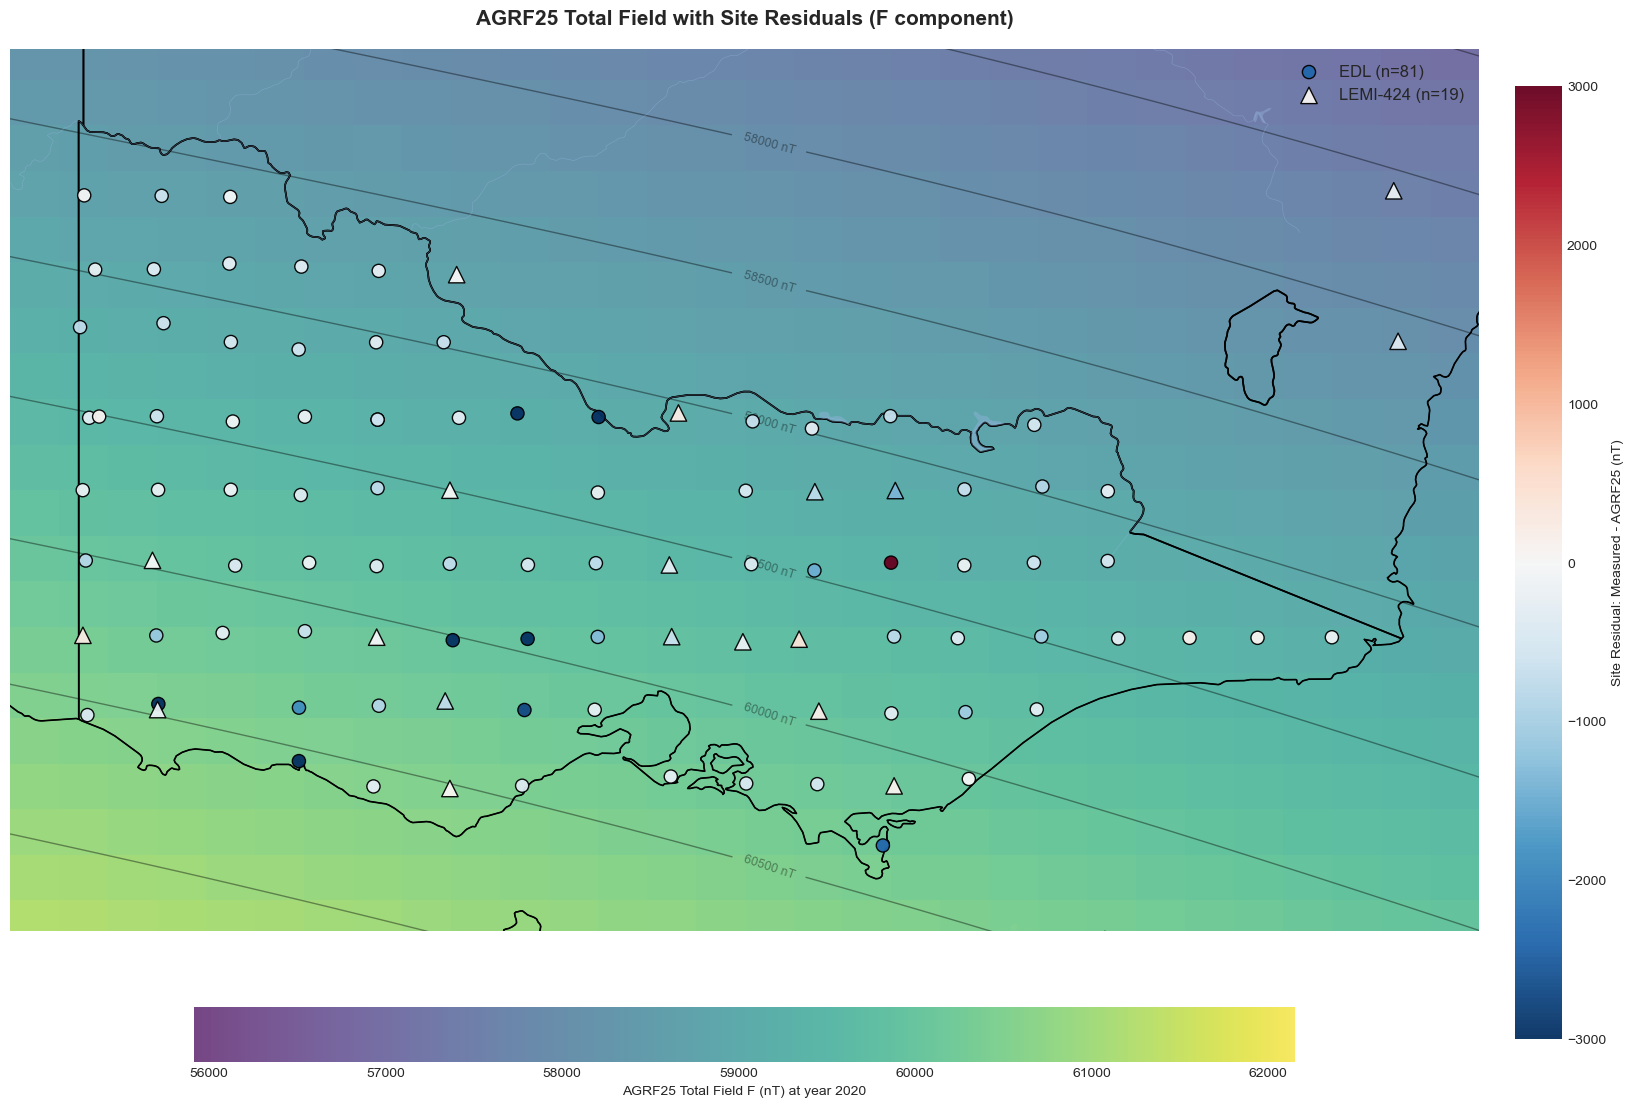

*Figure 8a. AGRF25 total field strength (F) as continuous color map, calculated at year 2020. Background AGRF field extends ~200 km beyond Victoria for smooth coverage. Contour lines at 500 nT intervals. Site locations color-coded by residual (measured - AGRF25): red = measured stronger, blue = measured weaker. Circles = EDL (2014, n=81), triangles = LEMI-424 (2016-2017, n=19). Mean residual = -656 nT. Systematic negative residuals indicate secular variation: Earth's field strengthened by ~656 nT between measurement epoch (2014-2017) and AGRF25 reference (2020).*

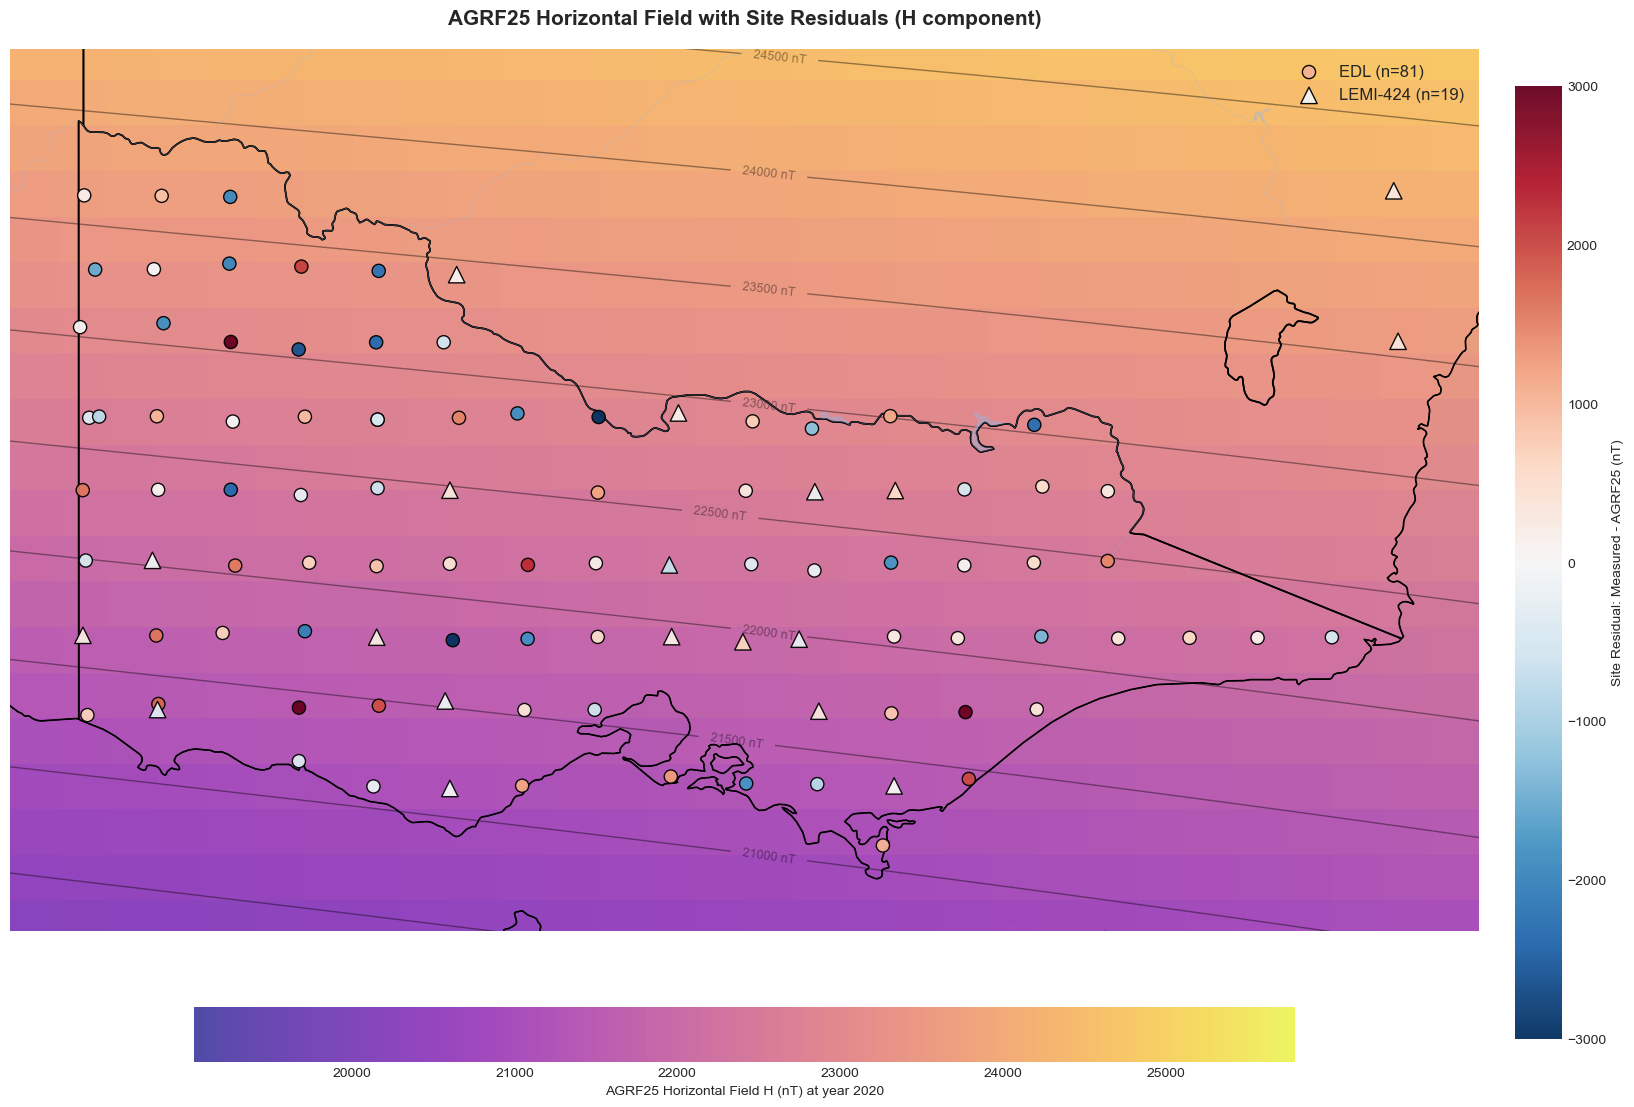

*Figure 8b. AGRF25 horizontal field strength (H) as continuous color map, calculated at year 2020. Background AGRF field extends ~200 km beyond Victoria for smooth coverage. Contour lines at 500 nT intervals. Site locations color-coded by residual (measured - AGRF25): red = measured stronger, blue = measured weaker. Circles = EDL (2014, n=81), triangles = LEMI-424 (2016-2017, n=19). Mean residual = -159 nT. Horizontal field shows greater spatial variability than total field, reflecting latitude-dependent geometry of Earth's magnetic field.*

In [21]:
# Create AGRF25 maps with site measurements overlay
# Note: AGRF25 model calculated at year 2020, while measurements are from 2014-2017

# Calculate mean residuals for caption
mean_total_residual = sites_for_map['total_residual'].mean()
mean_h_residual = sites_for_map['h_residual'].mean()

# Define map extent (Victoria only, but background extends ~200km beyond)
lat_extent = [-39.5, -33.5]  # Victoria boundaries
lon_extent = [140.5, 150.5]

# ============================================================================
# Figure 8a: Total Field (F) Map
# ============================================================================
fig = plt.figure(figsize=(18, 13))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_extent[0], lon_extent[1], lat_extent[0], lat_extent[1]], 
              crs=ccrs.PlateCarree())

# Plot AGRF25 total field as CONTINUOUS color map (extends beyond Victoria)
cf = ax.pcolormesh(lon_mesh, lat_mesh, agrf_total_grid,
                   cmap='viridis', alpha=0.7, shading='auto',
                   transform=ccrs.PlateCarree(), zorder=1)

# Add contour lines with improved readability
# Use round contour levels for easier reading
f_min, f_max = np.nanmin(agrf_total_grid), np.nanmax(agrf_total_grid)
contour_levels = np.arange(np.floor(f_min/500)*500, np.ceil(f_max/500)*500 + 1, 500)  # 500 nT intervals
contour_lines = ax.contour(lon_mesh, lat_mesh, agrf_total_grid,
                           levels=contour_levels, colors='black', alpha=0.4, linewidths=1.0,
                           transform=ccrs.PlateCarree(), zorder=2)
ax.clabel(contour_lines, inline=True, fontsize=9, fmt='%d nT', inline_spacing=10)

# Add geographic features
ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='none', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=1.2, zorder=4)
ax.add_feature(cfeature.LAKES, alpha=0.4, zorder=4)
ax.add_feature(cfeature.RIVERS, linewidth=0.5, alpha=0.4, zorder=4)

# Plot site measurements with color-coded residuals
norm_residual = Normalize(vmin=-3000, vmax=3000)
cmap_sites = cm.RdBu_r  # Red=high, Blue=low

for instrument, marker, size in [('EDL', 'o', 90), ('LEMI-424', '^', 140)]:
    subset = sites_for_map[sites_for_map['instrument'] == instrument]
    if len(subset) > 0:
        scatter = ax.scatter(subset['longitude'], subset['latitude'],
                           c=subset['total_residual'], cmap=cmap_sites, norm=norm_residual,
                           marker=marker, s=size, alpha=0.95,
                           edgecolors='black', linewidths=1.0,
                           transform=ccrs.PlateCarree(), zorder=6,
                           label=f'{instrument} (n={len(subset)})')

# Add colorbars
cbar_sites = plt.colorbar(scatter, ax=ax, orientation='vertical', pad=0.02, shrink=0.75,
                          label='Site Residual: Measured - AGRF25 (nT)')
cbar_sites.ax.tick_params(labelsize=10)

cbar_agrf = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.06, shrink=0.75,
                        label='AGRF25 Total Field F (nT) at year 2020')
cbar_agrf.ax.tick_params(labelsize=10)

ax.legend(loc='upper right', fontsize=12, framealpha=0.95, edgecolor='black')
ax.set_title('AGRF25 Total Field with Site Residuals (F component)', 
             fontsize=15, fontweight='bold', pad=18)

plt.tight_layout()
plt.show()

caption(f"Figure 8a. AGRF25 total field strength (F) as continuous color map, calculated at year 2020. "
        f"Background AGRF field extends ~200 km beyond Victoria for smooth coverage. "
        f"Contour lines at 500 nT intervals. "
        f"Site locations color-coded by residual (measured - AGRF25): red = measured stronger, blue = measured weaker. "
        f"Circles = EDL (2014, n={len(sites_for_map[sites_for_map['instrument']=='EDL'])}), "
        f"triangles = LEMI-424 (2016-2017, n={len(sites_for_map[sites_for_map['instrument']=='LEMI-424'])}). "
        f"Mean residual = {mean_total_residual:.0f} nT. Systematic negative residuals indicate secular variation: "
        f"Earth's field strengthened by ~{abs(mean_total_residual):.0f} nT between measurement epoch (2014-2017) and AGRF25 reference (2020).")

# ============================================================================
# Figure 8b: Horizontal Field (H) Map  
# ============================================================================
fig = plt.figure(figsize=(18, 13))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_extent[0], lon_extent[1], lat_extent[0], lat_extent[1]], 
              crs=ccrs.PlateCarree())

# Plot AGRF25 horizontal field as CONTINUOUS color map (extends beyond Victoria)
cf_h = ax.pcolormesh(lon_mesh, lat_mesh, agrf_h_grid,
                     cmap='plasma', alpha=0.7, shading='auto',
                     transform=ccrs.PlateCarree(), zorder=1)

# Add contour lines with improved readability
h_min, h_max = np.nanmin(agrf_h_grid), np.nanmax(agrf_h_grid)
contour_levels_h = np.arange(np.floor(h_min/500)*500, np.ceil(h_max/500)*500 + 1, 500)  # 500 nT intervals
contour_lines_h = ax.contour(lon_mesh, lat_mesh, agrf_h_grid,
                             levels=contour_levels_h, colors='black', alpha=0.4, linewidths=1.0,
                             transform=ccrs.PlateCarree(), zorder=2)
ax.clabel(contour_lines_h, inline=True, fontsize=9, fmt='%d nT', inline_spacing=10)

# Add geographic features
ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='none', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=1.2, zorder=4)
ax.add_feature(cfeature.LAKES, alpha=0.4, zorder=4)
ax.add_feature(cfeature.RIVERS, linewidth=0.5, alpha=0.4, zorder=4)

# Plot site measurements with color-coded residuals
for instrument, marker, size in [('EDL', 'o', 90), ('LEMI-424', '^', 140)]:
    subset = sites_for_map[sites_for_map['instrument'] == instrument]
    if len(subset) > 0:
        scatter_h = ax.scatter(subset['longitude'], subset['latitude'],
                              c=subset['h_residual'], cmap=cmap_sites, norm=norm_residual,
                              marker=marker, s=size, alpha=0.95,
                              edgecolors='black', linewidths=1.0,
                              transform=ccrs.PlateCarree(), zorder=6,
                              label=f'{instrument} (n={len(subset)})')

# Add colorbars
cbar_sites_h = plt.colorbar(scatter_h, ax=ax, orientation='vertical', pad=0.02, shrink=0.75,
                            label='Site Residual: Measured - AGRF25 (nT)')
cbar_sites_h.ax.tick_params(labelsize=10)

cbar_agrf_h = plt.colorbar(cf_h, ax=ax, orientation='horizontal', pad=0.06, shrink=0.75,
                           label='AGRF25 Horizontal Field H (nT) at year 2020')
cbar_agrf_h.ax.tick_params(labelsize=10)

ax.legend(loc='upper right', fontsize=12, framealpha=0.95, edgecolor='black')
ax.set_title('AGRF25 Horizontal Field with Site Residuals (H component)', 
             fontsize=15, fontweight='bold', pad=18)

plt.tight_layout()
plt.show()

caption(f"Figure 8b. AGRF25 horizontal field strength (H) as continuous color map, calculated at year 2020. "
        f"Background AGRF field extends ~200 km beyond Victoria for smooth coverage. "
        f"Contour lines at 500 nT intervals. "
        f"Site locations color-coded by residual (measured - AGRF25): red = measured stronger, blue = measured weaker. "
        f"Circles = EDL (2014, n={len(sites_for_map[sites_for_map['instrument']=='EDL'])}), "
        f"triangles = LEMI-424 (2016-2017, n={len(sites_for_map[sites_for_map['instrument']=='LEMI-424'])}). "
        f"Mean residual = {mean_h_residual:.0f} nT. Horizontal field shows greater spatial variability than total field, "
        f"reflecting latitude-dependent geometry of Earth's magnetic field.")

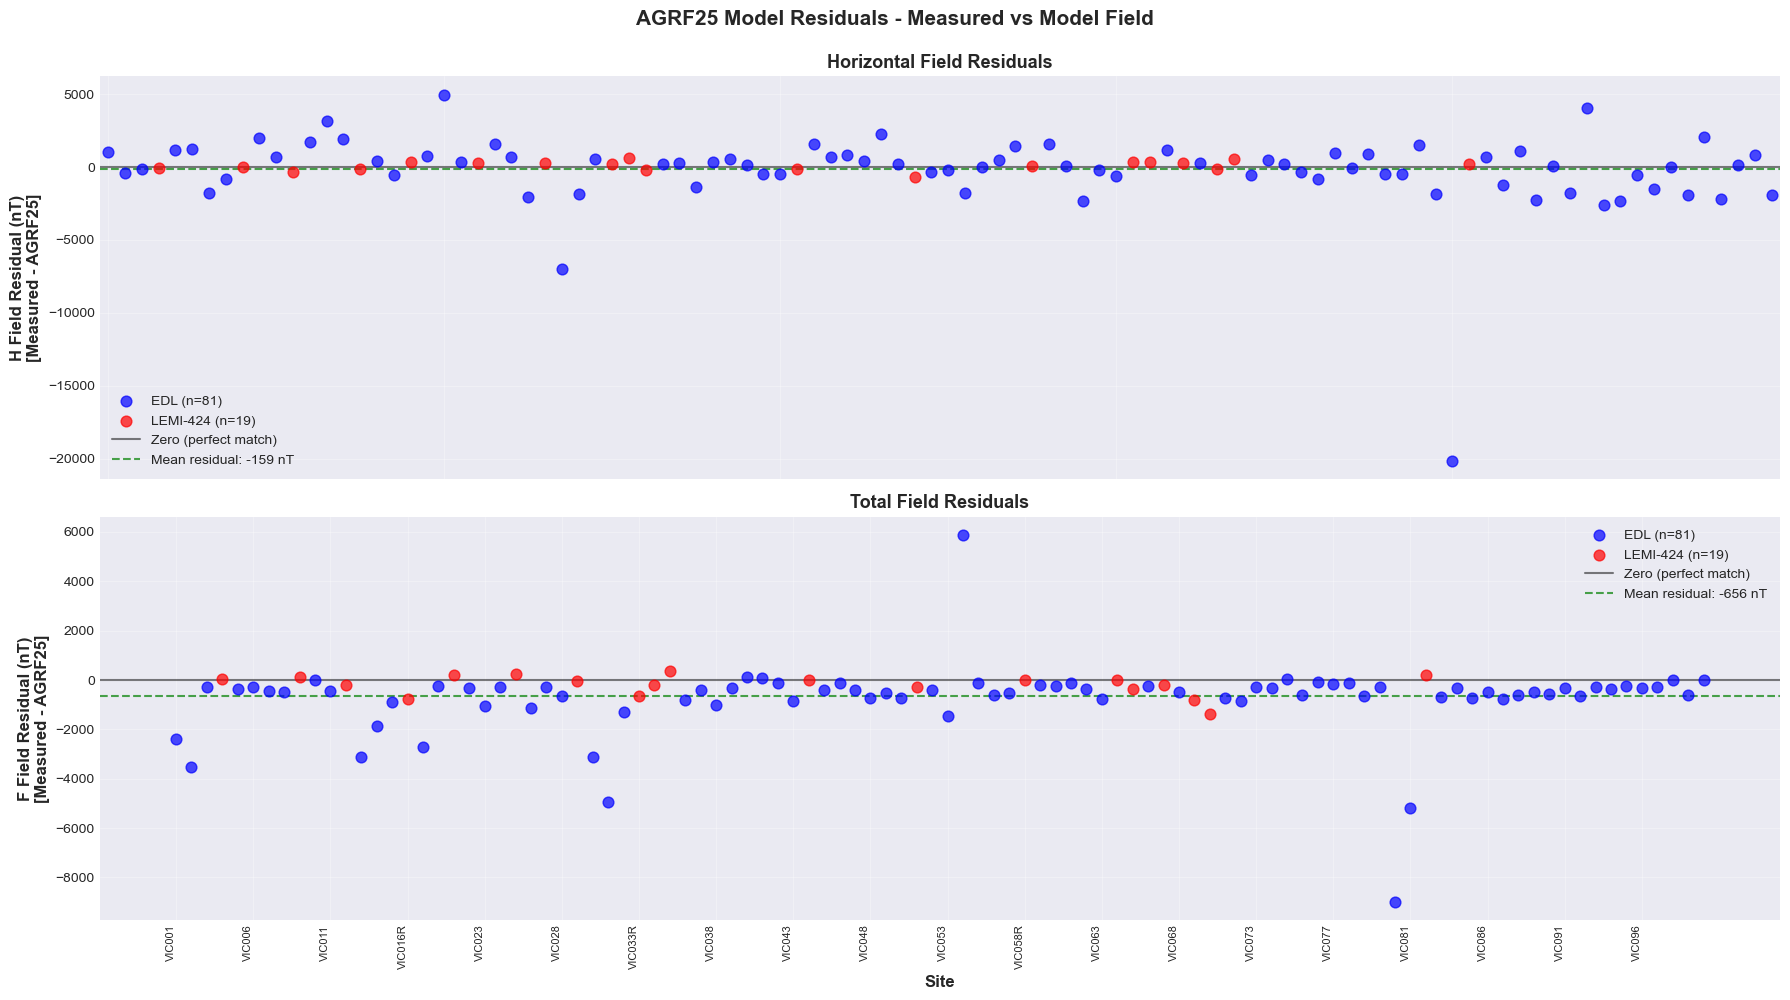

*Figure 7. Residuals between measured magnetic field and AGRF25 model predictions. Positive values indicate measured field is stronger than model prediction. Blue: EDL (n=81). Red: LEMI-424 (n=19). Black line shows zero residual (perfect match). Green dashed line shows mean residual. Large residuals may indicate: (1) temporal differences (data from 2014-2017 vs AGRF25 at 2020), (2) crustal magnetic anomalies, or (3) instrument calibration offsets. Mean offset of -656 nT in total field suggests systematic difference between measurement epoch and AGRF25 reference.*


AGRF25 Residual Statistics

Horizontal Field (H) Residuals:
  Mean:     -158.8 nT
  Median:    171.0 nT
  Std:      2499.0 nT
  Range:  -20162.5 to   4963.0 nT

Total Field (F) Residuals:
  Mean:     -655.8 nT
  Median:   -378.8 nT
  Std:      1412.4 nT
  Range:   -8973.0 to   5873.3 nT

Interpretation:
  • Mean residuals indicate systematic offset between measurement epoch and AGRF25
  • AGRF25 model is for year 2020, while measurements are from 2014 (EDL) and 2016-2017 (LEMI)
  • Secular variation accounts for ~656 nT over ~4-6 years
  • Individual site residuals may also reflect crustal magnetic anomalies


In [22]:
# Plot AGRF residuals (measured - model)
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

colors = {'EDL': 'blue', 'LEMI-424': 'red'}

# Horizontal field residual
ax = axes[0]
sites_h_res = sites_for_map.dropna(subset=['h_residual']).copy()
sites_h_res = sites_h_res.sort_values('site_id')

for instrument in ['EDL', 'LEMI-424']:
    subset = sites_h_res[sites_h_res['instrument'] == instrument]
    
    if len(subset) > 0:
        mask = sites_h_res['instrument'] == instrument
        x_instrument = [i for i, m in enumerate(mask) if m]
        y = subset['h_residual'].values
        ax.scatter(x_instrument, y, c=colors[instrument], alpha=0.7, s=60,
                  label=f'{instrument} (n={len(subset)})', zorder=3)

# Add zero line and mean residual
ax.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.5, label='Zero (perfect match)', zorder=2)
mean_h_res = sites_h_res['h_residual'].mean()
ax.axhline(mean_h_res, color='green', linestyle='--', linewidth=1.5, alpha=0.7,
          label=f'Mean residual: {mean_h_res:.0f} nT', zorder=2)

ax.set_ylabel('H Field Residual (nT)\n[Measured - AGRF25]', fontsize=12, fontweight='bold')
ax.set_title('Horizontal Field Residuals', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, zorder=1)
ax.set_xticklabels([])  # Hide labels on top plot
ax.set_xlim(-0.5, len(sites_h_res) - 0.5)

# Total field residual
ax = axes[1]
sites_f_res = sites_for_map.dropna(subset=['total_residual']).copy()
sites_f_res = sites_f_res.sort_values('site_id')

for instrument in ['EDL', 'LEMI-424']:
    subset = sites_f_res[sites_f_res['instrument'] == instrument]
    
    if len(subset) > 0:
        mask = sites_f_res['instrument'] == instrument
        x_instrument = [i for i, m in enumerate(mask) if m]
        y = subset['total_residual'].values
        ax.scatter(x_instrument, y, c=colors[instrument], alpha=0.7, s=60,
                  label=f'{instrument} (n={len(subset)})', zorder=3)

# Add zero line and mean residual
ax.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.5, label='Zero (perfect match)', zorder=2)
mean_f_res = sites_f_res['total_residual'].mean()
ax.axhline(mean_f_res, color='green', linestyle='--', linewidth=1.5, alpha=0.7,
          label=f'Mean residual: {mean_f_res:.0f} nT', zorder=2)

ax.set_ylabel('F Field Residual (nT)\n[Measured - AGRF25]', fontsize=12, fontweight='bold')
ax.set_xlabel('Site', fontsize=12, fontweight='bold')
ax.set_title('Total Field Residuals', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, zorder=1)

# Set x-axis ticks with site names

# Set x-axis limits for alignment
ax.set_xlim(-0.5, len(sites_f_res) - 0.5)

# Set x-axis ticks with ALL site names
tick_positions = range(len(sites_f_res))
tick_labels = sites_f_res['site_id'].values
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, fontsize=8, ha='right')

plt.suptitle('AGRF25 Model Residuals - Measured vs Model Field', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

caption(f"Figure 7. Residuals between measured magnetic field and AGRF25 model predictions. "
        f"Positive values indicate measured field is stronger than model prediction. "
        f"Blue: EDL (n={len(sites_f_res[sites_f_res['instrument']=='EDL'])}). "
        f"Red: LEMI-424 (n={len(sites_f_res[sites_f_res['instrument']=='LEMI-424'])}). "
        f"Black line shows zero residual (perfect match). Green dashed line shows mean residual. "
        f"Large residuals may indicate: (1) temporal differences (data from 2014-2017 vs AGRF25 at 2020), "
        f"(2) crustal magnetic anomalies, or (3) instrument calibration offsets. "
        f"Mean offset of {mean_f_res:.0f} nT in total field suggests systematic difference between measurement epoch and AGRF25 reference.")

# Print residual statistics
print("\n" + "="*70)
print("AGRF25 Residual Statistics")
print("="*70)
print(f"\nHorizontal Field (H) Residuals:")
print(f"  Mean:   {sites_h_res['h_residual'].mean():>8.1f} nT")
print(f"  Median: {sites_h_res['h_residual'].median():>8.1f} nT")
print(f"  Std:    {sites_h_res['h_residual'].std():>8.1f} nT")
print(f"  Range:  {sites_h_res['h_residual'].min():>8.1f} to {sites_h_res['h_residual'].max():>8.1f} nT")

print(f"\nTotal Field (F) Residuals:")
print(f"  Mean:   {sites_f_res['total_residual'].mean():>8.1f} nT")
print(f"  Median: {sites_f_res['total_residual'].median():>8.1f} nT")
print(f"  Std:    {sites_f_res['total_residual'].std():>8.1f} nT")
print(f"  Range:  {sites_f_res['total_residual'].min():>8.1f} to {sites_f_res['total_residual'].max():>8.1f} nT")

print(f"\nInterpretation:")
print(f"  • Mean residuals indicate systematic offset between measurement epoch and AGRF25")
print(f"  • AGRF25 model is for year 2020, while measurements are from 2014 (EDL) and 2016-2017 (LEMI)")
print(f"  • Secular variation accounts for ~{abs(mean_f_res):.0f} nT over ~4-6 years")
print(f"  • Individual site residuals may also reflect crustal magnetic anomalies")
print("="*70)